In [108]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [109]:
base_dir = os.path.dirname(os.path.abspath('.'))

In [110]:
df = pd.read_csv('./data/Pnoe_20251124_1109-Jadidi_Parastou 4.csv', delimiter=';')
# Convert all columns to numeric where possible, coercing errors to NaN
df = df.apply(pd.to_numeric, errors='ignore')
df['VO2 Pulse'] = df['VO2(ml/min)'] / df['HR(bpm)']  # VO2 Pulse in mL/beat
df['VO2 Breath'] = df['VO2(ml/min)'] / df['BF(bpm)']  # VO2 per Breath in mL/breath
df['CHO'] = df['EE(kcal/min)'] * df['CARBS(%)']/100
df['FAT'] = df['EE(kcal/min)'] * df['FAT(%)']/100
# Smooth key columns using rolling window
window_size = 10

# List of columns to smooth
columns_to_smooth = ['VO2(ml/min)', 'VCO2(ml/min)', 'HR(bpm)', 'VT(l)', 'BF(bpm)', 'VE(l/min)', 'VO2 Pulse', 'VO2 Breath', 'CHO', 'FAT']

# Apply forward-looking smoothing to each column
for col in columns_to_smooth:
    if col in df.columns:
        # Reverse, apply rolling, then reverse back to get forward-looking average
        df[f'{col}_smoothed'] = df[col].rolling(window=window_size).mean()

print("Smoothed columns created:")
print([col for col in df.columns if '_smoothed' in col])

Smoothed columns created:
['VO2(ml/min)_smoothed', 'VCO2(ml/min)_smoothed', 'HR(bpm)_smoothed', 'VT(l)_smoothed', 'BF(bpm)_smoothed', 'VE(l/min)_smoothed', 'VO2 Pulse_smoothed', 'VO2 Breath_smoothed', 'CHO_smoothed', 'FAT_smoothed']


/tmp/ipykernel_84362/931005767.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors='ignore')


In [111]:
df_2 = pd.read_excel('./data/SECA body comp for all patients.xlsx')
spirometry_data = pd.read_csv('./data/spirometry_data.csv')
oxygenation = pd.read_csv('./data/Keirstyn Train Red NIRS Muscle Oxygen.csv')
oxygenation_2 = pd.read_csv('./data/muscle_oxygenation.csv', skiprows=445)

In [112]:
print(df['VO2 Pulse'].max())

23.22783439490446


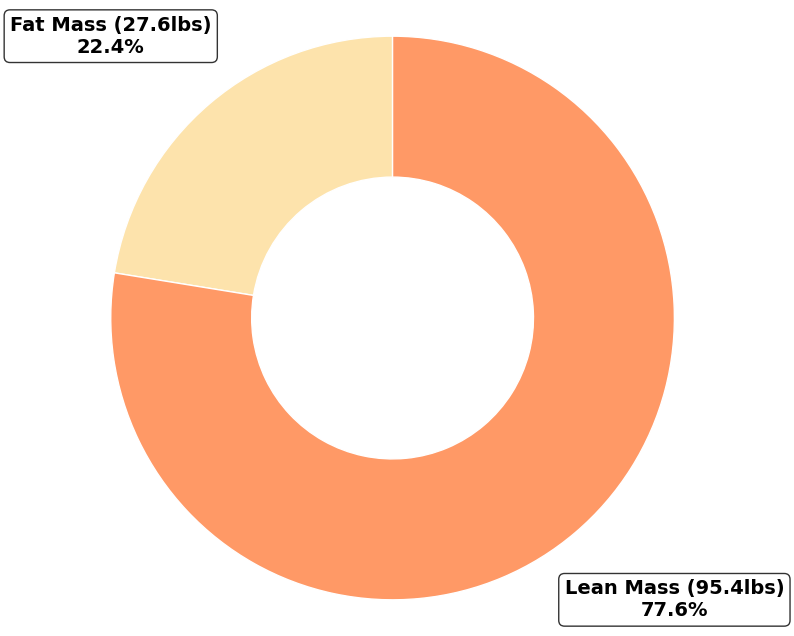

In [113]:
# Filter df_2 for Keirstyn Moran
keirstyn_data = df_2[df_2['LastName'].str.contains('Moran', case=False, na=False)]
# Get the fat mass percentage for Keirstyn
fat_percentage = keirstyn_data['Adult_FMP'].iloc[0]
weight_kg = keirstyn_data['Weight'].iloc[0]
age = keirstyn_data['Age'].iloc[0]
gender = keirstyn_data['Gender'].iloc[0]
lean_percentage = 100 - fat_percentage

# Create donut chart
fat_mass_lbs = 27.6
lean_mass_lbs = 95.4

# Calculate percentages from the provided weights
total_weight = fat_mass_lbs + lean_mass_lbs
fat_percentage = (fat_mass_lbs / total_weight) * 100
lean_percentage = (lean_mass_lbs / total_weight) * 100

# Data for the chart
sizes = [fat_percentage, lean_percentage]
colors = ['#fde3ac', '#ff9966'] # Light yellow/tan and orange from the image
plt.figure(figsize=(8, 8))

# Create the donut chart without labels first
wedges, texts, autotexts = plt.pie(sizes,
                                   autopct='',  # Remove auto percentages
                                   startangle=90,
                                   wedgeprops=dict(width=0.5, edgecolor='w'),
                                   colors=colors,
                                   labels=['', ''])  # Remove default labels

# Add custom text annotations positioned manually
plt.text(-1, 1, 'Fat Mass (27.6lbs)\n22.4%', 
         fontsize=14, fontweight='bold', ha='center', va='center',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.text(1, -1, 'Lean Mass (95.4lbs)\n77.6%', 
         fontsize=14, fontweight='bold', ha='center', va='center',
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

# Set the title
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

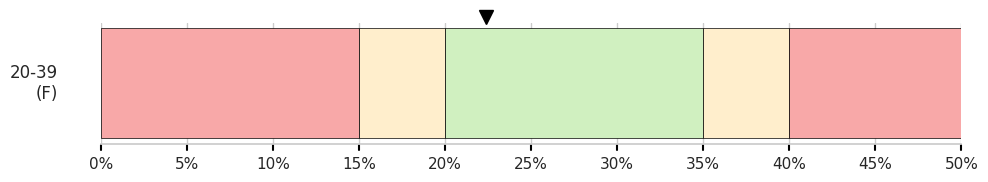

In [114]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a common style
sns.set_theme(style="whitegrid")

# Define the segments with muted colors
segments = [
    ('#F8A8A8', 0, 15),     # Muted Red/Salmon: 0% to 15%
    ('#FFEECC', 15, 5),     # Pale Yellow/Cream: 15% to 20%
    ('#D0F0C0', 20, 15),    # Pale Green/Mint: 20% to 35%
    ('#FFEECC', 35, 5),     # Pale Yellow/Cream: 35% to 40%
    ('#F8A8A8', 40, 10)     # Muted Red/Salmon: 40% to 50%
]

target_value = 22.4
demographic = "20-39\n(F)"

fig, ax = plt.subplots(figsize=(10, 2))

# Create the Segmented Bar
for color, start, length in segments:
    ax.barh(y=0, width=length, left=start, height=1, color=color, edgecolor='black', linewidth=0.5)

# Add the Indicator (Triangle)
ax.plot(target_value, 1.05, marker='v', color='black', markersize=10, clip_on=False, transform=ax.get_xaxis_transform())

# Set Axis Properties and Labels
ax.set_xlim(0, 50)
ax.set_xticks(range(0, 51, 5))
ax.set_yticks([])
ax.text(-0.05, 0, demographic, transform=ax.get_yaxis_transform(), va='center', ha='right', fontsize=12)

ax.set_xlim(0, 50)
ticks = range(0, 51, 5)
ax.set_xticks(ticks)
labels = [f"{t}%" for t in ticks]
ax.set_xticklabels(labels)
# Clean up spines and add small ticks
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.spines['bottom'].set_visible(True)

for x in range(0, 51, 5):
    ax.plot([x, x], [-0.05, -0.01], color='black', transform=ax.get_xaxis_transform(), clip_on=False)

plt.tight_layout()
plt.show() # This is where the file is saved and displayed above.

Displaying Metabolism Chart...
Measured RMR: 1369 kcal/day, Predicted (Mifflin-St Jeor): 1242 kcal/day, Ratio: 1.10


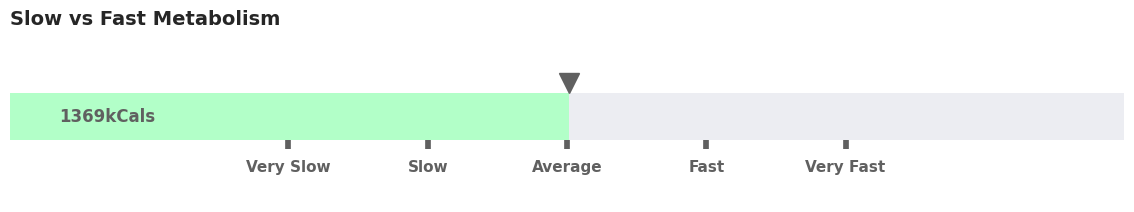


Displaying Fuel Source Chart...
Resting phase fuel mix: Fats 33.2%, Carbs 66.8%


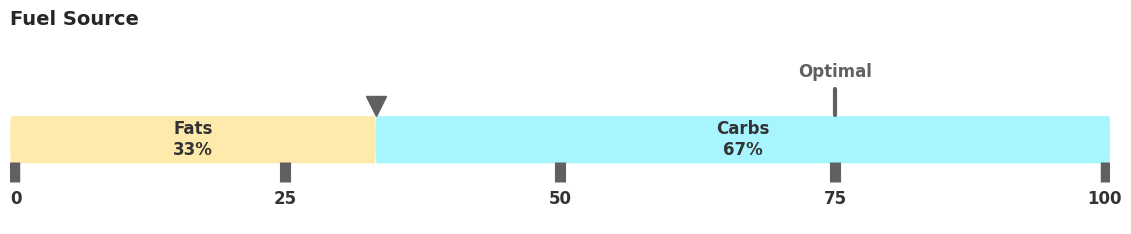

In [115]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Enable inline display for matplotlib
%matplotlib inline

def mifflin_st_jeor(weight_kg, height_cm, age_years, sex):
    """
    Computes the Mifflin-St Jeor predicted RMR (kcal/day).
    sex must be "male" or "female"
    """
    if sex.lower() == "male":
        return 10 * weight_kg + 6.25 * height_cm - 5 * age_years + 5
    elif sex.lower() == "female":
        return 10 * weight_kg + 6.25 * height_cm - 5 * age_years - 161
    else:
        raise ValueError(f"sex should be 'male' or 'female', got {sex}")

def rmr_classification(ratio):
    if ratio < 0.7:
        return 'Very Slow'
    elif 0.7 <= ratio < 0.9:
        return 'Slow'
    elif 0.9 <= ratio <= 1.1:
        return 'Average'
    elif 1.1 < ratio <= 1.3:
        return 'Fast'
    else:
        return 'Very Fast'

def plot_metabolism_chart(weight_kg, height_cm, age_years, sex, df, fig_width=11.5, fig_height=2.5):
    """
    Generates a 'Slow vs Fast Metabolism' chart styled to match the provided sample:
    - Bar is rectangular (not curved).
    - First and last ticks are omitted, no tick at 0.3 and 1.9.
    - Ticks are thicker and positioned below the bar (don't encroach).
    - All text labels are bold.
    - (Modified) A gap is added between the title and the graph.
    - Text color, tick color, and triangle are all gray.
    - (MODIFIED) The main horizontal bar is now THICKER.
    """
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # set global uniform width

    # Identify resting phase and measured RMR
    rest_phase = df[df['MET'] <= 1.1]  # assuming <1.1 MET = rest
    measured_rmr = rest_phase['EE(kcal/day)'].mean()
    mifflin_rmr = mifflin_st_jeor(weight_kg, height_cm, age_years, sex)
    ratio = measured_rmr / mifflin_rmr if mifflin_rmr > 0 else float('nan')
    print(f"Measured RMR: {measured_rmr:.0f} kcal/day, Predicted (Mifflin-St Jeor): {mifflin_rmr:.0f} kcal/day, Ratio: {ratio:.2f}")

    # Bar setup
    scale_edges = [0.3, 0.7, 0.9, 1.1, 1.3, 1.5, 1.9]  # bar runs from 0.3 to 1.9
    scale_labels = ['Very Slow', 'Slow', 'Average', 'Fast', 'Very Fast']
    tick_edges = scale_edges[1:-1]  # remove first and last tick (omit 0.3 and 1.9)

    x_start = scale_edges[0]
    x_end = scale_edges[-1]
    # ---- Make the bar THICKER by increasing bar_height and adjusting y_bar ----
    bar_height = 0.36
    y_bar = 0.48
    # ---------------------------------------------------------------------------

    color_before = "#B2FFC8"
    color_after = "#ECEDF2"
    gray_color = "#606060"   # new variable for consistent gray

    # Draw plain rectangle bar (no rounding)
    ax.add_patch(
        patches.Rectangle(
            (x_start, y_bar), x_end - x_start, bar_height,
            ec='none', fc=color_after, lw=0
        )
    )
    # Highlighted rectangle
    highlight_end = min(max(ratio, x_start), x_end)
    if highlight_end > x_start:
        ax.add_patch(
            patches.Rectangle(
                (x_start, y_bar), highlight_end - x_start, bar_height,
                ec='none', fc=color_before, lw=0
            )
        )

    # kCals label, left-aligned, bold inside green, TEXT COLOR now gray
    ax.text(
        x_start + 0.07, y_bar + bar_height/2,
        f"{int(round(measured_rmr))}kCals",
        ha="left", va="center",
        color=gray_color,
        fontsize=12, weight='bold',
        bbox=dict(boxstyle="round,pad=0.14", ec="none", fc="#B2FFC8", alpha=1.0)
    )

    # Triangle marker above highlight end, now gray
    ax.plot(
        [highlight_end], [y_bar + bar_height + 0.08],
        marker='v', markersize=14, color=gray_color, clip_on=False
    )

    # Draw ticks – omit leftmost/rightmost (thicker and below bar), color gray
    tick_width = 4.1
    tick_bottom = y_bar - 0.07  # further below bar
    tick_top = y_bar  # at the base of bar
    for edge in tick_edges:
        ax.plot([edge, edge], [tick_bottom, tick_top], color=gray_color, lw=tick_width, solid_capstyle='butt', clip_on=False, zorder=2)

    # Label locations (place directly under each tick), text color gray
    label_y = tick_bottom - 0.08
    for label, tick in zip(scale_labels, tick_edges):
        ax.text(
            tick, label_y, label, ha='center', va='top',
            fontsize=11, weight='bold',
            color=gray_color
        )
    # Axis title: bold, with extra gap above the graph, color gray
    ax.text(
        x_start, y_bar + bar_height + 0.5,  # changed 0.11 -> 0.17 for more gap
        "Slow vs Fast Metabolism", ha='left', va='bottom',
        fontsize=14, weight='bold'
    )

    ax.set_xlim(x_start, x_end)
    ax.set_ylim(0, 1)
    ax.axis('off')

    plt.tight_layout()
    plt.close(fig)
    return fig

def frange(start, stop, step):
    vals = []
    while start < stop - step/2:
        vals.append(round(start, 10))
        start += step
    return vals

def plot_fuel_source_chart(fig_width=11.5, fig_height=2.5):
    """
    Generates and displays the 'Fuel Source' chart.
    Uniform width/height for match.
    """
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))  # uniform width/height

    rest_phase = df[df['RER'] == 0.9]
    fat_rest = rest_phase['FAT(%)'].mean()
    carb_rest = rest_phase['CARBS(%)'].mean()
    print(f"Resting phase fuel mix: Fats {fat_rest:.1f}%, Carbs {carb_rest:.1f}%")

    fat_percentage = fat_rest
    carb_percentage = 100 - fat_percentage
    optimal_point = 75

    # Let the bars be a bit thicker as well: increase bar height and y
    fats_bar = patches.FancyBboxPatch(
        (0, 0.36), fat_percentage, 0.28,
        boxstyle="round,pad=0,rounding_size=0.1",
        ec="none", fc="#FEEAAB",
    )
    ax.add_patch(fats_bar)
    carbs_bar = patches.FancyBboxPatch(
        (fat_percentage, 0.36), carb_percentage, 0.28,
        boxstyle="round,pad=0,rounding_size=0.1",
        ec="none", fc="#A7F5FF",
    )
    ax.add_patch(carbs_bar)

    # Style: match font weight/color/size with other chart
    label_fontprops = dict(fontsize=12, weight='bold', color='#333333')

    ax.text(fat_percentage / 2, 0.5, f'Fats\n{fat_percentage:.0f}%', 
            ha='center', va='center', **label_fontprops)
    ax.text(fat_percentage + carb_percentage / 2, 0.5, f'Carbs\n{100-fat_percentage:.0f}%', 
            ha='center', va='center', **label_fontprops)

    ax.text(optimal_point, 0.9, 'Optimal', ha='center', va='center', fontsize=12, weight='bold', color='#606060')
    ax.plot([optimal_point, optimal_point], [0.65, 0.8], color='#606060', lw=3)

    ax.plot(fat_percentage, 0.7, 'v', markersize=15, color='#606060', clip_on=False)

    positions = [0, 25, 50, 75, 100]
    # Gray color for all ticks
    tick_color = '#606060'
    for pos in positions:
        # Smallest ticks (first and last)
        if pos == 0:
            ax.text(pos + 0.5, 0.15, str(pos), ha='center', va='center', fontsize=12, color='#333333', weight='bold')
            ax.plot([pos, pos], [0.25, 0.37], color=tick_color, lw=14, solid_capstyle='butt')
        elif pos == 100:
            ax.text(pos - 0.5, 0.15, str(pos), ha='center', va='center', fontsize=12, color='#333333', weight='bold')
            ax.plot([pos, pos], [0.25, 0.37], color=tick_color, lw=14, solid_capstyle='butt')
        else:
            ax.text(pos, 0.15, str(pos), ha='center', va='center', fontsize=12, color='#333333', weight='bold')
            ax.plot([pos, pos], [0.25, 0.37], color=tick_color, lw=8, solid_capstyle='butt')
    # Uniform style for title
    ax.set_title('Fuel Source', fontsize=14, weight='bold', loc='left', pad=22)
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 1)
    ax.axis('off')

    plt.tight_layout()
    plt.close(fig)
    return fig

if __name__ == '__main__':
    weight_kg = 56
    height_cm = 162
    age_years = 34
    sex = "female"
    print("Displaying Metabolism Chart...")
    fig1 = plot_metabolism_chart(weight_kg, height_cm, age_years, sex, df)
    display(fig1)
    
    print("\nDisplaying Fuel Source Chart...")
    fig2 = plot_fuel_source_chart()
    display(fig2)

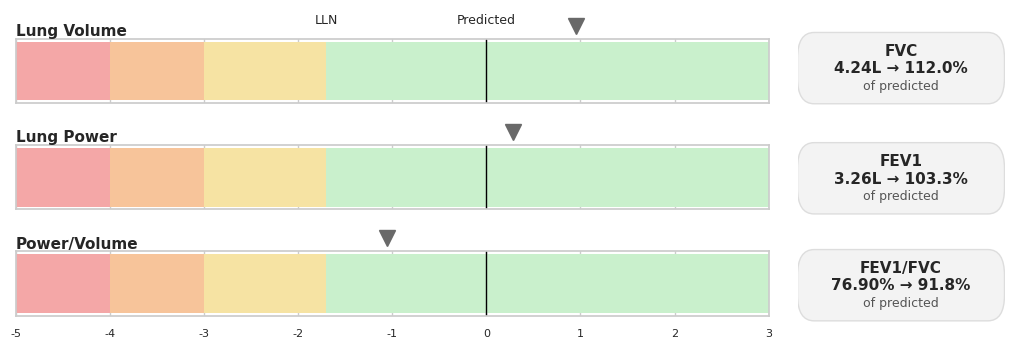

In [116]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
from matplotlib.patches import FancyBboxPatch
# Ensure data is loaded
try:
    spirometry_df = spirometry_data.copy()
except NameError:
    spirometry_df = pd.read_csv('data/spirometry_data.csv')

# Coerce numeric columns
for col in ['Best', 'LLN', 'Pred.', '%Pred.', 'ZScore']:
    if col in spirometry_df.columns:
        spirometry_df[col] = pd.to_numeric(spirometry_df[col], errors='coerce')

# Select rows of interest and prepare display values
rows_map = {
    'Lung Volume': 'FVC',
    'Lung Power': 'FEV1',
    'Power/Volume': 'FEV1/FVC%'
}

records = []
for label, param in rows_map.items():
    row = spirometry_df.loc[spirometry_df['Parameters'].str.strip() == param]
    if row.empty:
        continue
    row = row.iloc[0]
    records.append({
        'label': label,
        'param': param,
        'best': row['Best'],
        'pct': row['%Pred.'],
        'z': row['ZScore']
    })

# Figure setup
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(11.5, 3.6), sharex=True,
                        gridspec_kw={'hspace': 0.65})

x_min, x_max = -5, 3
# Segment colors: red -> orange -> yellow -> green
segments = [
    (-5, -4, '#f4a7a7'),   # red-ish
    (-4, -3, '#f7c49a'),   # orange-ish
    (-3, -1.7, '#f6e3a3'),   # yellow-ish
    (-1.7,  3, '#c9f0cc'),   # green-ish
]

ticks = np.arange(x_min, x_max + 1, 1)
labels = [str(i) for i in ticks]

# Plot each row
for ax, rec in zip(axes, records):
    # Background segments
    for a, b, color in segments:
        ax.barh(0, width=b-a, left=a, height=0.6, color=color, edgecolor='none')

    # LLN (-1) and Predicted (0) markers
    # ax.axvline(-1, color='black', lw=1)
    ax.axvline(0, color='black', lw=1)

    # Z-score pointer (downward triangle) at top of each panel
    if pd.notna(rec['z']):
        trans = mtransforms.blended_transform_factory(ax.transData, ax.transAxes)
        ax.plot(float(rec['z']), 1.2, marker='v', markersize=12, color='dimgray',
                transform=trans, clip_on=False)

    # Labels, ticks, and styling
    ax.set_title(rec['label'], loc='left', fontsize=11, fontweight='bold', pad=2)
    ax.set_xlim(x_min, x_max)
    ax.set_yticks([])
    ax.set_xticks(ticks)
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_xlabel('')

# Add x-axis label to the bottom axis
# axes[-1].set_xlabel('Z-score', fontsize=10)

# Top annotations
axes[0].text(-1.7, 0.45, 'LLN', ha='center', va='bottom', fontsize=9)
axes[0].text(0, 0.45, 'Predicted', ha='center', va='bottom', fontsize=9)

# Right-side summary boxes
fig.subplots_adjust(right=0.78)
box_ax = fig.add_axes([0.805, 0.06, 0.18, 0.90])  # [left, bottom, width, height]
box_ax.axis('off')

# Helper to draw a pill-shaped text box

def pill(ax, xy, text):
    x, y = xy
    # Draw rounded rectangle background
    bbox = FancyBboxPatch((x-0.48, y-0.09), 0.96, 0.18,
                          boxstyle='round,pad=0.02,rounding_size=0.08',
                          ec='#dddddd', fc='#f3f3f3', linewidth=1.0)
    ax.add_patch(bbox)
    ax.text(x, y+0.025, text, ha='center', va='center', fontsize=11, fontweight='bold')
    ax.text(x, y-0.055, 'of predicted', ha='center', va='center', fontsize=9, color='#555555')

box_ax.set_xlim(0, 1)
box_ax.set_ylim(0, 1)

# Prepare display strings and positions (top to bottom)
right_items = []
for rec in records:
    name = 'FVC' if rec['param'] == 'FVC' else ('FEV1' if rec['param'] == 'FEV1' else 'FEV1/FVC')
    unit = 'L' if rec['param'] in ('FVC', 'FEV1') else '%'
    value_fmt = f"{rec['best']:.2f}{unit}"
    pct_fmt = f"{rec['pct']:.1f}%"
    right_items.append((name, value_fmt, pct_fmt))

# Sort to match image order on the right (FVC, FEV1, FEV1/FVC)
order = ['FVC', 'FEV1', 'FEV1/FVC']
right_items_sorted = [next(item for item in right_items if item[0] == k) for k in order]

ys = [0.82, 0.48, 0.15]
for (name, value_fmt, pct_fmt), y in zip(right_items_sorted, ys):
    main_line = f"{name}\n{value_fmt} → {pct_fmt}"
    pill(box_ax, (0.5, y), main_line)

##plt.savefig(f'{base_dir}/graphs/spirometry_chart.png', dpi=300, bbox_inches='tight')
plt.show()

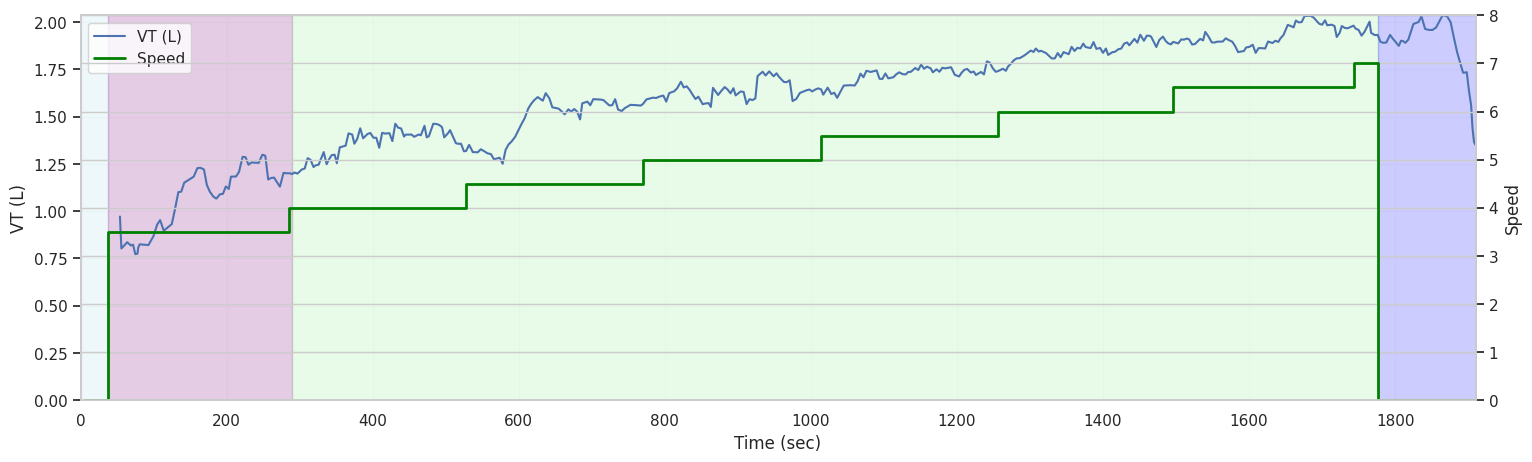

In [117]:
first_unique_phase = df.drop_duplicates(subset='PHASE')
phase_times = first_unique_phase['T(sec)'].tolist()

plt.figure(figsize=(18, 5))
ax1 = plt.subplot()

# Plot VT with step-like appearance
line1 = sns.lineplot(data=df, x='T(sec)', y='VT(l)_smoothed', label='VT (L)')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('VT (L)')
ax1.grid(True, alpha=0.1)
ax1.set_ylim(0, min(8, df['VT(l)_smoothed'].max()))

# Set x-axis limits to remove padding
ax1.set_xlim(0, df['T(sec)'].max())

# Plot speed as step function on secondary y-axis
ax2 = ax1.twinx()
ax1.set_xticks(np.arange(0, df['T(sec)'].max(), 200))
line2 = sns.lineplot(data=df, x='T(sec)', y='Speed', color='green', ax=ax2, 
             drawstyle='steps-post', linewidth=2, label='Speed')
ax2.set_ylabel('Speed')
ax2.set_ylim(0, min(30, df['Speed'].max()) + 1)

# Remove default legends first
ax1.get_legend().remove()
ax2.get_legend().remove()

# Combine legends from both axes in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add colored background regions if you have phase information
ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

#plt.savefig(f'{base_dir}/graphs/respiratory.png', dpi=300, bbox_inches='tight')
plt.show()

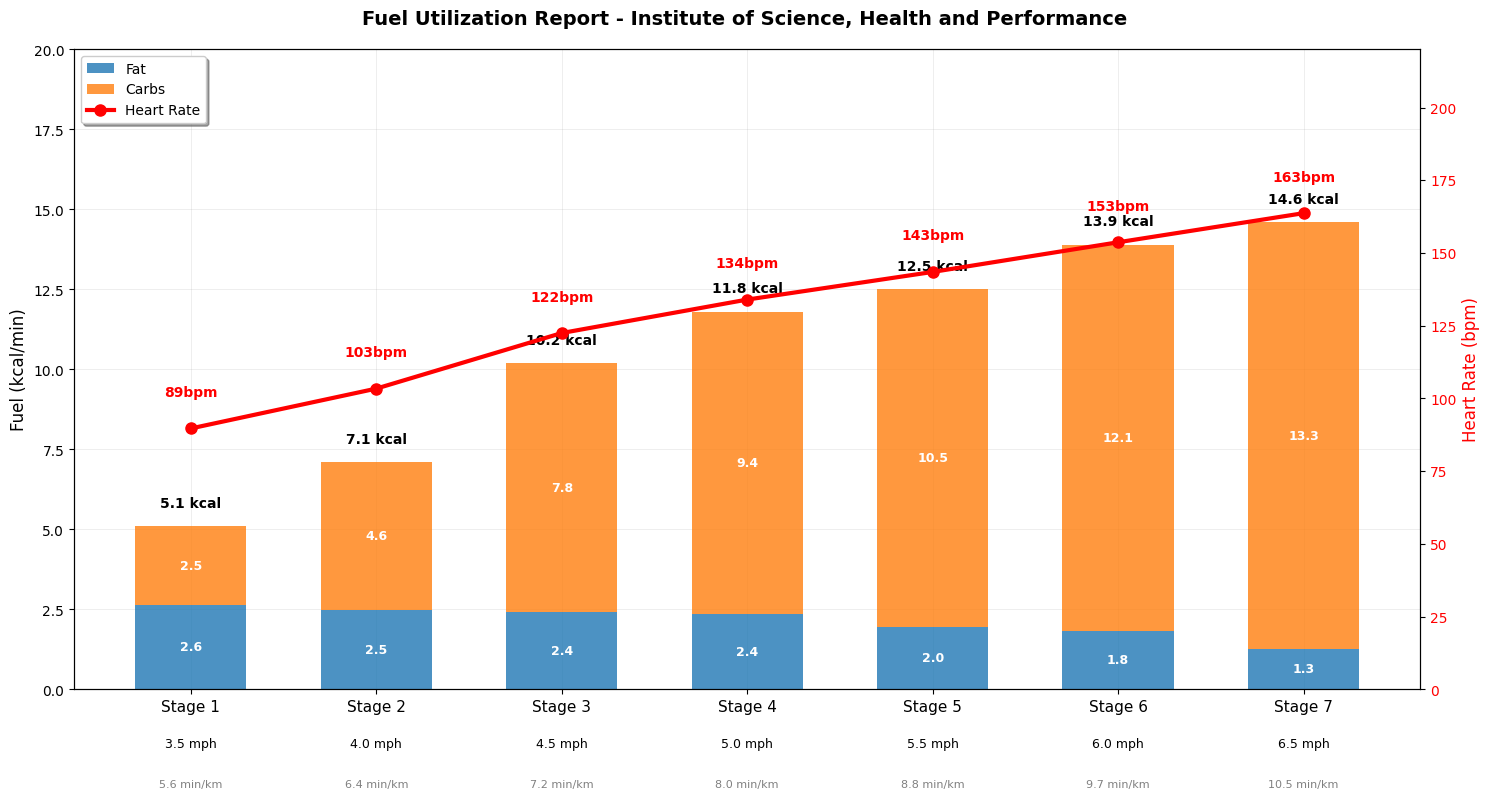

In [118]:

# Group by speed and calculate mean for numeric columns only
speed_groups = df.groupby('Speed').mean(numeric_only=True).round(1)

# Drop the first and last row from speed_groups
speed_groups = speed_groups.iloc[1:-1]

# Filter data to only include speeds in the desired range
filtered_data = speed_groups[(speed_groups.index >= 3.5) & (speed_groups.index <= 7.5)]

# Create figure with specific size
plt.figure(figsize=(15, 8))
plt.style.use('default')

# Create stage labels and positions
stage_labels = [f'Stage {i}' for i in range(1, len(filtered_data) + 1)]
x_positions = np.arange(len(filtered_data))

# Calculate fat and carbs energy expenditure from percentages
fat_ee = filtered_data['EE(kcal/min)'] * filtered_data['FAT(%)'] / 100
carbs_ee = filtered_data['EE(kcal/min)'] * filtered_data['CARBS(%)'] / 100

# Create the main axis for the stacked bars
ax1 = plt.gca()

# Create stacked bar chart with colors
bars_fat = ax1.bar(x_positions, fat_ee, color='#1f77b4', alpha=0.8, width=0.6, label='Fat')
bars_carbs = ax1.bar(x_positions, carbs_ee, bottom=fat_ee, color='#ff7f0e', alpha=0.8, width=0.6, label='Carbs')

# Set labels and formatting for primary axis
ax1.set_xlabel('', fontsize=12)
ax1.set_ylabel('Fuel (kcal/min)', fontsize=12)
ax1.set_ylim(0, 20)

# Add individual values on each bar segment
for i, (fat_val, carb_val, total_val) in enumerate(zip(fat_ee, carbs_ee, filtered_data['EE(kcal/min)'])):
    if fat_val > 0.3:  # Fat value
        ax1.text(i, fat_val/2, f'{fat_val:.1f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')
    if carb_val > 0.3:  # Carbs value
        ax1.text(i, fat_val + carb_val/2, f'{carb_val:.1f}', ha='center', va='center',
                 fontsize=9, fontweight='bold', color='white')
    # Total EE
    ax1.text(i, total_val + 0.5, f'{total_val:.1f} kcal', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='black')

# Add speed labels below x-axis
for i, speed in enumerate(filtered_data.index):
    ax1.text(i, -1.5, f'{speed:.1f} mph', ha='center', va='top', fontsize=9)
    ax1.text(i, -2.8, f'{speed*1.609:.1f} min/km', ha='center', va='top', fontsize=8, color='gray')

# Create secondary y-axis for heart rate
ax2 = ax1.twinx()

# Plot heart rate line (no manual offset)
hr_line = ax2.plot(x_positions, filtered_data['HR(bpm)'],
                   marker='o', linewidth=3, markersize=8, color='red', label='Heart Rate')

# Set heart rate axis formatting
ax2.set_ylabel('Heart Rate (bpm)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Dynamically adjust HR axis to float above bars
max_bar_height = max(filtered_data['EE(kcal/min)'])
ax2.set_ylim(0, 220)  # ensures HR line is above bars


# Add HR values above the points
for i, hr in enumerate(filtered_data['HR(bpm)']):
    ax2.text(i, hr + 10, f'{int(hr)}bpm', ha='center', va='bottom',
             fontsize=10, fontweight='bold', color='red')

# Set x-axis formatting
ax1.set_xticks(x_positions)
ax1.set_xticklabels(stage_labels, fontsize=11)

# Add title
plt.suptitle('Fuel Utilization Report - Institute of Science, Health and Performance',
             fontsize=14, fontweight='bold', y=0.95)

# Create legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left',
           frameon=True, fancybox=True, shadow=True)

# Add grid
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_axisbelow(True)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.1, top=0.9)
#plt.savefig(f'{base_dir}/graphs/fuel_utilization_chart.png', dpi=300)
plt.show()

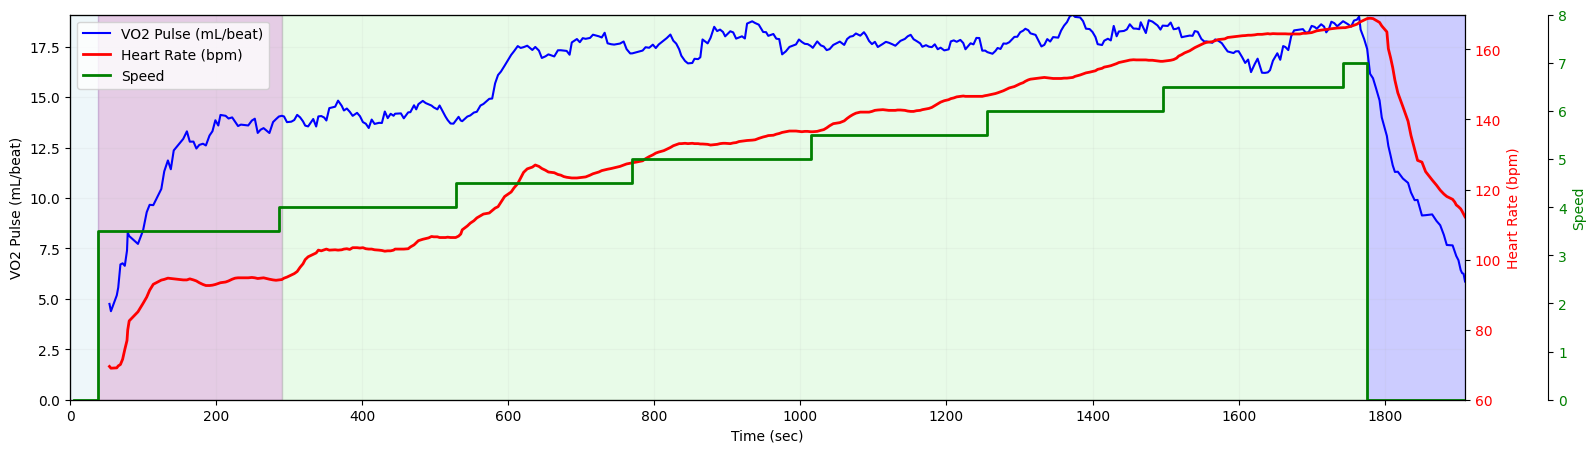

In [119]:
first_unique_phase = df.drop_duplicates(subset='PHASE')
phase_times = first_unique_phase['T(sec)'].tolist()

plt.figure(figsize=(18, 5))
ax1 = plt.subplot()

# Plot VO2 Pulse
#
line1 = sns.lineplot(data=df, x='T(sec)', y='VO2 Pulse_smoothed', label='VO2 Pulse (mL/beat)', color='blue')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('VO2 Pulse (mL/beat)')
# ax1.set_title('VO2 Pulse, Heart Rate, and Speed Over Time')
ax1.set_ylim(0, df['VO2 Pulse_smoothed'].max())
ax1.grid(True, alpha=0.1)
# Set x-axis limits to remove padding
ax1.set_xlim(0, df['T(sec)'].max())
# Create second y-axis for heart rate
#
ax2 = ax1.twinx()
line2 = sns.lineplot(data=df, x='T(sec)', y='HR(bpm)_smoothed', color='red', ax=ax2, 
                     linewidth=2, label='Heart Rate (bpm)')
ax2.set_ylabel('Heart Rate (bpm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.set_ylim(60, df['HR(bpm)_smoothed'].max() + 1)

# Create third y-axis for speed
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))

line3 = sns.lineplot(data=df, x='T(sec)', y='Speed', color='green', ax=ax3, 
                     drawstyle='steps-post', linewidth=2, label='Speed')
ax3.set_ylabel('Speed', color='green')
ax3.tick_params(axis='y', labelcolor='green')
ax3.set_ylim(0, df['Speed'].max() + 1)

ax1.set_xticks(np.arange(0, df['T(sec)'].max(), 200))

# Remove default legends first
if ax1.get_legend():
    ax1.get_legend().remove()
if ax2.get_legend():
    ax2.get_legend().remove()
if ax3.get_legend():
    ax3.get_legend().remove()

# Combine legends from all axes in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

# Add colored background regions if you have phase information
ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

#plt.savefig(f'{base_dir}/graphs/vo2_pulse_chart.png', bbox_inches='tight', dpi=300)
plt.show()

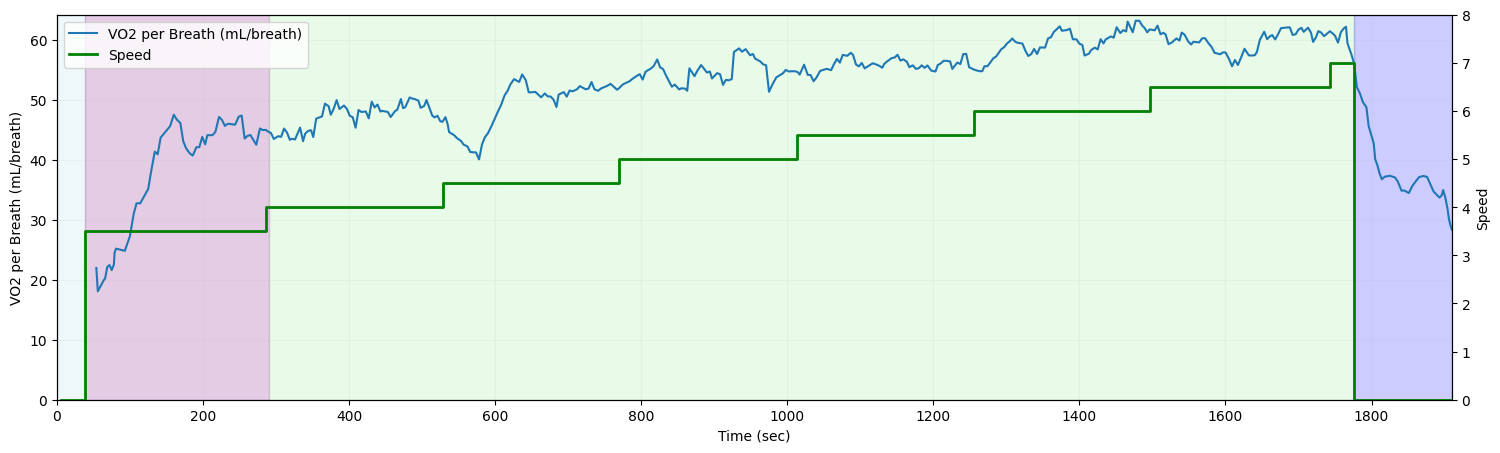

In [120]:
first_unique_phase = df.drop_duplicates(subset='PHASE')
phase_times = first_unique_phase['T(sec)'].tolist()

plt.figure(figsize=(18, 5))
ax1 = plt.subplot()

# Plot VT with step-like appearance
line1 = sns.lineplot(data=df, x='T(sec)', y='VO2 Breath_smoothed', label='VO2 per Breath (mL/breath)')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('VO2 per Breath (mL/breath)')
# ax1.set_title('VO2 per Breath and Speed Over Time')
ax1.set_ylim(0, df['VO2 Breath_smoothed'].max() + 1)
ax1.grid(True, alpha=0.1)
# Set x-axis limits to remove padding
ax1.set_xlim(0, df['T(sec)'].max())

# Plot speed as step function on secondary y-axis
ax2 = ax1.twinx()
ax1.set_xticks(np.arange(0, df['T(sec)'].max(), 200))
line2 = sns.lineplot(data=df, x='T(sec)', y='Speed', color='green', ax=ax2, 
             drawstyle='steps-post', linewidth=2, label='Speed')
ax2.set_ylim(0, df['Speed'].max() + 1)
ax2.set_ylabel('Speed')

# Remove default legends first
ax1.get_legend().remove()
ax2.get_legend().remove()

# Combine legends from both axes in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add colored background regions if you have phase information
ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

#plt.savefig(f'{base_dir}/graphs/vo2_breath_chart.png', bbox_inches='tight', dpi=300)
plt.show()

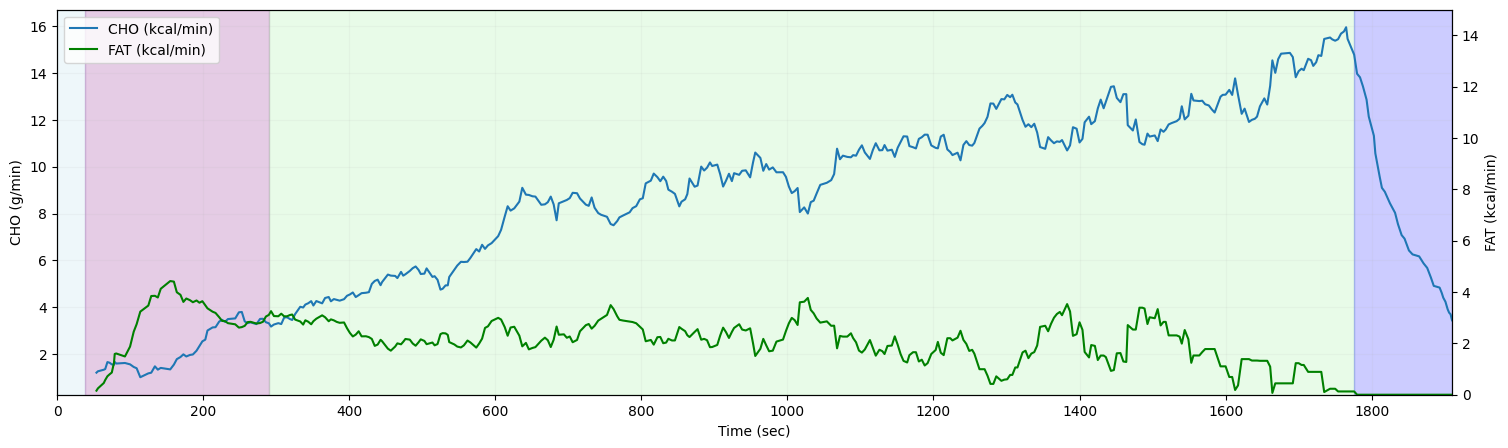

In [121]:
first_unique_phase = df.drop_duplicates(subset='PHASE')
phase_times = first_unique_phase['T(sec)'].tolist()

plt.figure(figsize=(18, 5))
ax1 = plt.subplot()

df['CHO']
# Plot VT with step-like appearance
line1 = sns.lineplot(data=df, x='T(sec)', y='CHO_smoothed', label='CHO (kcal/min)')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('CHO (g/min)')
# ax1.set_title('CHO and Speed Over Time')
ax1.grid(True, alpha=0.1)
# Set x-axis limits to remove padding
ax1.set_xlim(0, df['T(sec)'].max())
# Plot speed as step function on secondary y-axis
ax2 = ax1.twinx()
ax1.set_xticks(np.arange(0, df['T(sec)'].max(), 200))
line2 = sns.lineplot(data=df, x='T(sec)', y='FAT_smoothed', color='green', ax=ax2, label='FAT (kcal/min)')
ax2.set_ylabel('FAT (kcal/min)')

ax2.set_ylim(0, 15)  # ensures HR line is above bars

# Remove default legends first
ax1.get_legend().remove()
ax2.get_legend().remove()

# Combine legends from both axes in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Add colored background regions if you have phase information
ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

#plt.savefig(f'{base_dir}/graphs/fat_metabolism_chart.png', bbox_inches='tight', dpi=300)
plt.show()

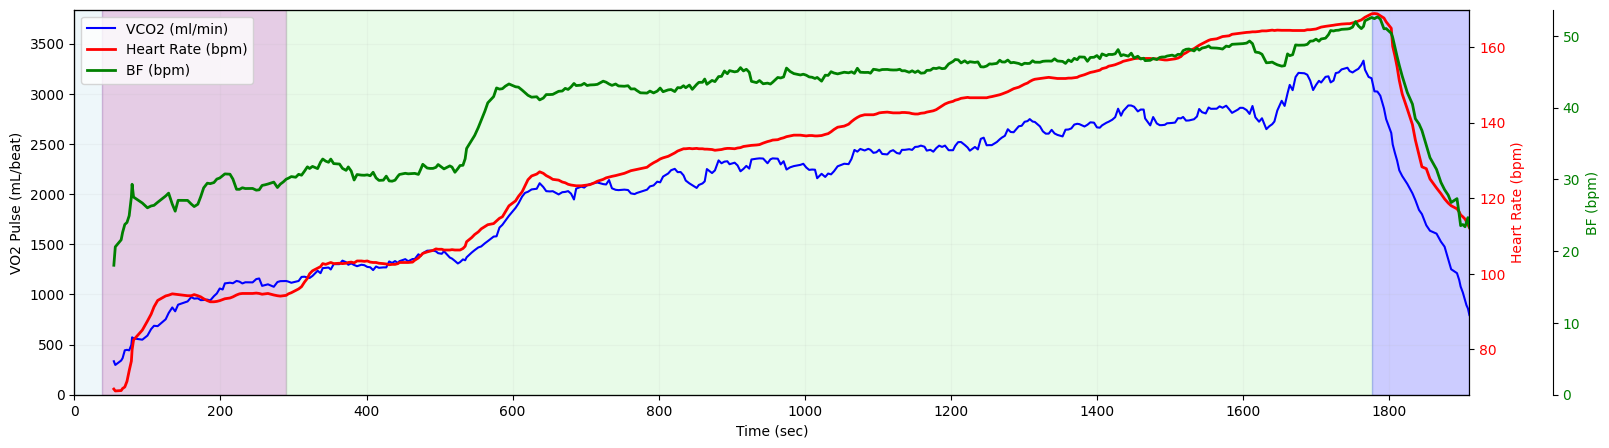

In [122]:
first_unique_phase = df.drop_duplicates(subset='PHASE')
phase_times = first_unique_phase['T(sec)'].tolist()

plt.figure(figsize=(18, 5))
ax1 = plt.subplot()

# Plot VO2 Pulse
line1 = sns.lineplot(data=df, x='T(sec)', y='VCO2(ml/min)_smoothed', label='VCO2 (ml/min)', color='blue')
ax1.set_xlabel('Time (sec)')
ax1.set_ylabel('VO2 Pulse (mL/beat)')
# ax1.set_title('VO2 Pulse, Heart Rate, and Speed Over Time')
ax1.set_ylim(0, df['VCO2(ml/min)'].max())
ax1.grid(True, alpha=0.1)
# Set x-axis limits to remove padding
ax1.set_xlim(0, df['T(sec)'].max())

# Create second y-axis for heart rate
ax2 = ax1.twinx()
line2 = sns.lineplot(data=df, x='T(sec)', y='HR(bpm)_smoothed', color='red', ax=ax2, 
                     linewidth=2, label='Heart Rate (bpm)')
ax2.set_ylabel('Heart Rate (bpm)', color='red')
ax2.set_ylim(df['HR(bpm)_smoothed'].min() - 1, df['HR(bpm)_smoothed'].max() + 1)
ax2.tick_params(axis='y', labelcolor='red')

# Create third y-axis for speed
ax3 = ax1.twinx()
ax3.spines['right'].set_position(('outward', 60))
line3 = sns.lineplot(data=df, x='T(sec)', y='BF(bpm)_smoothed', color='green', ax=ax3, linewidth=2, label='BF (bpm)')
ax3.set_ylabel('BF (bpm)', color='green')
ax3.tick_params(axis='y', labelcolor='green')
ax3.set_ylim(0, df['BF(bpm)_smoothed'].max() + 1)
ax1.set_xticks(np.arange(0, df['T(sec)'].max(), 200))

# Remove default legends first
if ax1.get_legend():
    ax1.get_legend().remove()
if ax2.get_legend():
    ax2.get_legend().remove()
if ax3.get_legend():
    ax3.get_legend().remove()

# Combine legends from all axes in the top left
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
lines3, labels3 = ax3.get_legend_handles_labels()
ax1.legend(lines1 + lines2 + lines3, labels1 + labels2 + labels3, loc='upper left')

# Add colored background regions if you have phase information
ax1.axvspan(0, phase_times[1], alpha=0.2, color='lightblue')
ax1.axvspan(phase_times[1], phase_times[2], alpha=0.2, color='purple')
ax1.axvspan(phase_times[2], phase_times[3], alpha=0.2, color='lightgreen')
ax1.axvspan(phase_times[3], df['T(sec)'].max(), alpha=0.2, color='blue')

#plt.savefig(f'{base_dir}/graphs/recovery_chart.png', bbox_inches='tight', dpi=300)
plt.show()

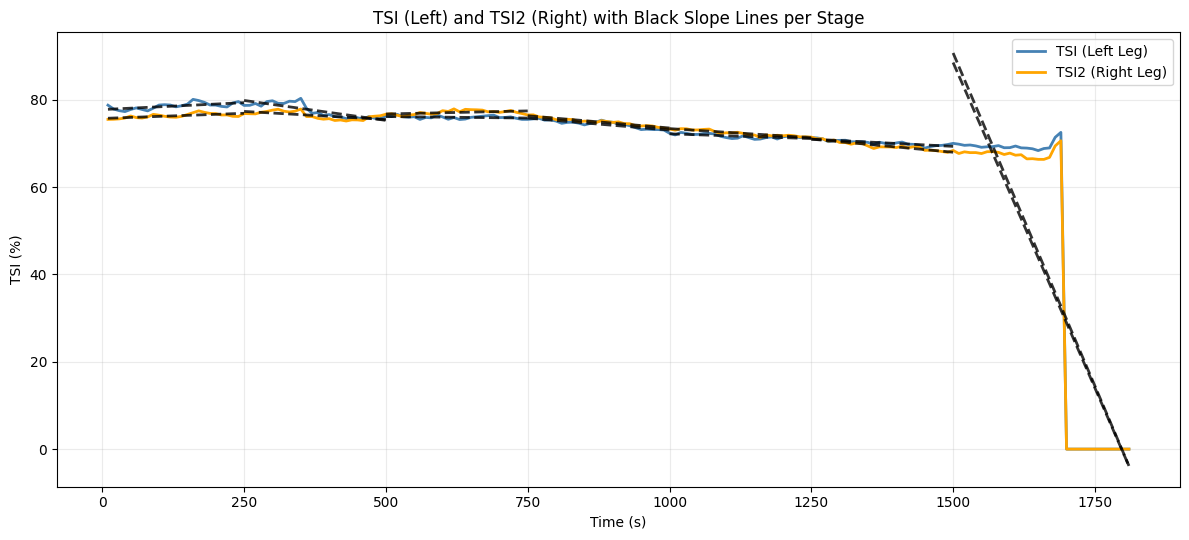

In [123]:
# Plot TSI (Left) and TSI2 (Right) with Black Slope (Trend) Lines per Stage
from numpy.polynomial.polynomial import Polynomial

plt.figure(figsize=(12, 5.5))

# Plot TSI (Left Leg)
plt.plot(
    oxygenation['Time'], oxygenation['TSI'], 
    label='TSI (Left Leg)', color='steelblue', linewidth=2
)

# Plot TSI2 (Right Leg)
plt.plot(
    oxygenation['Time'], oxygenation['TSI-second'],
    label='TSI2 (Right Leg)', color='orange', linewidth=2
)

# Define time intervals for stages (adjust these based on your test protocol)
# Looking at the data range, we'll create intervals
max_time = oxygenation['Time'].max()
intervals = [
    (0, 250),
    (250, 500),
    (500, 750),
    (750, 1000),
    (1000, 1250),
    (1250, 1500),
    (1500, max_time)
]

# Calculate and plot trend lines for each interval
for start_time, end_time in intervals:
    # Filter data for this interval
    mask_interval = (oxygenation['Time'] >= start_time) & (oxygenation['Time'] <= end_time)
    
    # TSI (Left Leg) trend for this interval
    mask_left = mask_interval & ~oxygenation['TSI'].isna()
    if mask_left.sum() > 1:  # Need at least 2 points for a line
        x_left = oxygenation.loc[mask_left, 'Time']
        y_left = oxygenation.loc[mask_left, 'TSI']
        coefs_left = Polynomial.fit(x_left, y_left, 1).convert().coef
        trend_left = coefs_left[0] + coefs_left[1] * x_left
        plt.plot(x_left, trend_left, color='black', linestyle='--', linewidth=2, alpha=0.8)
    
    # TSI-second (Right Leg) trend for this interval
    mask_right = mask_interval & ~oxygenation['TSI-second'].isna()
    if mask_right.sum() > 1:  # Need at least 2 points for a line
        x_right = oxygenation.loc[mask_right, 'Time']
        y_right = oxygenation.loc[mask_right, 'TSI-second']
        coefs_right = Polynomial.fit(x_right, y_right, 1).convert().coef
        trend_right = coefs_right[0] + coefs_right[1] * x_right
        plt.plot(x_right, trend_right, color='black', linestyle='--', linewidth=2, alpha=0.8)

plt.xlabel('Time (s)')
plt.ylabel('TSI (%)')
plt.title('TSI (Left) and TSI2 (Right) with Black Slope Lines per Stage')
plt.legend(fontsize=10, loc='upper right')
plt.tight_layout()
plt.grid(alpha=0.25)
# #plt.savefig('graphs/tsi_comparison_with_trends.png', bbox_inches='tight', dpi=160)
plt.show()

Age: 45, Gender: male, VO2 Max: 35.5
Age Range: 40-49, Category: Poor


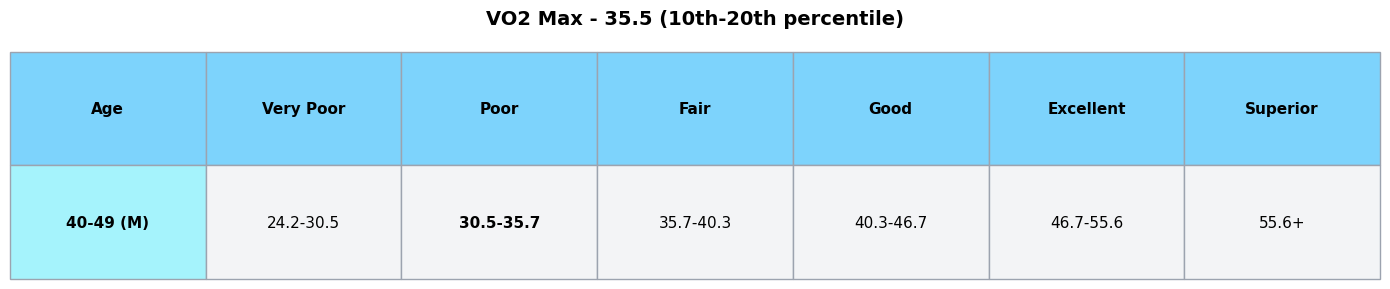

In [124]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.table import Table
import numpy as np

# VO2 Max Master Chart Data
VO2_MASTER_CHART = {
    'male': {
        '20-29': {
            'Very Poor': (29.0, 38.1),
            'Poor': (38.1, 44.9),
            'Fair': (44.9, 50.2),
            'Good': (50.2, 61.8),
            'Excellent': (57.1, 66.3),
            'Superior': (66.3, None)  # None means open-ended
        },
        '30-39': {
            'Very Poor': (27.2, 34.1),
            'Poor': (34.1, 39.6),
            'Fair': (39.6, 45.2),
            'Good': (45.2, 51.6),
            'Excellent': (51.6, 59.8),
            'Superior': (59.8, None)
        },
        '40-49': {
            'Very Poor': (24.2, 30.5),
            'Poor': (30.5, 35.7),
            'Fair': (35.7, 40.3),
            'Good': (40.3, 46.7),
            'Excellent': (46.7, 55.6),
            'Superior': (55.6, None)
        },
        '50-59': {
            'Very Poor': (20.9, 26.1),
            'Poor': (26.1, 30.7),
            'Fair': (30.7, 35.1),
            'Good': (35.1, 41.2),
            'Excellent': (41.2, 50.7),
            'Superior': (50.7, None)
        },
        '60-69': {
            'Very Poor': (17.4, 22.4),
            'Poor': (22.4, 26.6),
            'Fair': (26.6, 30.5),
            'Good': (30.5, 36.1),
            'Excellent': (36.1, 43.0),
            'Superior': (43.0, None)
        }
    },
    'female': {
        '20-29': {
            'Very Poor': (21.7, 28.6),
            'Poor': (28.6, 34.6),
            'Fair': (34.6, 40.6),
            'Good': (40.6, 46.5),
            'Excellent': (46.5, 56.0),
            'Superior': (56.0, None)
        },
        '30-39': {
            'Very Poor': (19.0, 24.1),
            'Poor': (24.1, 28.2),
            'Fair': (28.2, 32.2),
            'Good': (32.2, 35.7),
            'Excellent': (35.7, 45.8),
            'Superior': (45.8, None)
        },
        '40-49': {
            'Very Poor': (17.0, 21.3),
            'Poor': (21.3, 24.9),
            'Fair': (24.9, 28.7),
            'Good': (28.7, 34.0),
            'Excellent': (34.0, 41.7),
            'Superior': (41.7, None)
        },
        '50-59': {
            'Very Poor': (16.0, 19.1),
            'Poor': (19.1, 24.4),
            'Fair': (21.8, 27.6),
            'Good': (25.2, 28.6),
            'Excellent': (28.6, 35.9),
            'Superior': (35.9, None)
        },
        '60-69': {
            'Very Poor': (13.4, 16.5),
            'Poor': (16.5, 18.9),
            'Fair': (18.9, 21.2),
            'Good': (21.2, 24.6),
            'Excellent': (24.6, 29.4),
            'Superior': (29.4, None)
        }
    }
}

def get_age_range(age):
    """Determine age range from age in years."""
    if 20 <= age <= 29:
        return '20-29'
    elif 30 <= age <= 39:
        return '30-39'
    elif 40 <= age <= 49:
        return '40-49'
    elif 50 <= age <= 59:
        return '50-59'
    elif 60 <= age <= 69:
        return '60-69'
    else:
        # Default to closest range
        if age < 20:
            return '20-29'
        elif age >= 70:
            return '60-69'
        else:
            return '30-39'  # fallback

def determine_category(vo2_max, age_range, gender):
    """Determine VO2 max category based on value, age, and gender."""
    gender_key = 'male' if gender.lower().startswith('m') else 'female'
    ranges = VO2_MASTER_CHART[gender_key][age_range]
    
    categories = ['Very Poor', 'Poor', 'Fair', 'Good', 'Excellent', 'Superior']
    
    # Check Superior category first (open-ended)
    min_val, max_val = ranges['Superior']
    if max_val is None and vo2_max >= min_val:
        print(f"It is always superior")
        return 'Superior'
    
    # Check other categories from Excellent down to Very Poor
    # Ranges are typically [min, max) - inclusive of min, exclusive of max
    # But when value equals max, it belongs to the next category
    for category in reversed(categories[:-1]):  # Exclude Superior as we already checked it
        min_val, max_val = ranges[category]
        # Check if value falls in this range (inclusive of min, exclusive of max)
        if min_val <= vo2_max < max_val:
            return category
    
    # If value is below all ranges, return Very Poor
    # This handles the case where vo2_max < min of Very Poor
    return 'Very Poor'

def format_range(min_val, max_val):
    """Format range as string."""
    if max_val is None:
        return f"{min_val}+"
    else:
        return f"{min_val}-{max_val}"

def generate_vo2_max_table(age, gender, vo2_max_value, save_path=None):
    """
    Generate VO2 Max table with indicator arrow.
    
    Args:
        age: Patient age in years
        gender: 'male' or 'female' (or 'm'/'f')
        vo2_max_value: Patient's VO2 max value
        save_path: Optional path to save the figure
    
    Returns:
        fig, ax: matplotlib figure and axes
    """
    # Determine age range and category
    age_range = get_age_range(age)
    category = determine_category(vo2_max_value, age_range, gender)
    
    # Debug: print the determined category
    print(f"Age: {age}, Gender: {gender}, VO2 Max: {vo2_max_value}")
    print(f"Age Range: {age_range}, Category: {category}")
    
    # Get the appropriate data
    gender_key = 'male' if gender.lower().startswith('m') else 'female'
    ranges = VO2_MASTER_CHART[gender_key][age_range]
    
    # Prepare table data
    headers = ['Age', 'Very Poor', 'Poor', 'Fair', 'Good', 'Excellent', 'Superior']
    age_label = f"{age_range} ({gender[0].upper()})"
    
    row_data = [age_label]
    for cat in ['Very Poor', 'Poor', 'Fair', 'Good', 'Excellent', 'Superior']:
        min_val, max_val = ranges[cat]
        row_data.append(format_range(min_val, max_val))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(14, 3))
    ax.axis('off')
    
    # Create table
    table_data = [headers, row_data]
    table = ax.table(cellText=table_data,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Header row styling (cyan background)
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#7dd3fc')  # cyan-300 equivalent
        cell.set_text_props(weight='bold', color='black')
        cell.set_edgecolor('#9ca3af')  # gray-400
        cell.set_linewidth(1)
    
    # Find the column index for the category (before styling)
    category_index = headers.index(category)
    
    # Data row styling
    for i in range(len(row_data)):
        cell = table[(1, i)]
        if i == 0:  # Age column
            cell.set_facecolor('#a5f3fc')  # cyan-200
            cell.set_text_props(weight='semibold', color='black')
        else:
            cell.set_facecolor('#f3f4f6')  # gray-100
            cell.set_text_props(color='black')
            # Bold the cell that corresponds to the patient's category
            if i == category_index:
                cell.set_text_props(weight='bold', color='black')
        cell.set_edgecolor('#9ca3af')  # gray-400
        cell.set_linewidth(1)
    
    # Add arrow indicator below the category column
    # Calculate position
    cell_width = 1.0 / len(headers)
    arrow_x = (category_index + 0.5) * cell_width
    
    # Draw arrow pointing up
    arrow = patches.FancyArrowPatch(
        (arrow_x, -0.15), (arrow_x, -0.05),
        arrowstyle='->', mutation_scale=20, 
        linewidth=2, color='black',
        transform=ax.transAxes
    )
    ax.add_patch(arrow)
    
    # Add triangle at the top
    triangle = patches.RegularPolygon(
        (arrow_x, -0.05), 3, radius=0.02,
        orientation=np.pi/2, color='black',
        transform=ax.transAxes
    )
    ax.add_patch(triangle)
    
    # Set title - calculate approximate percentile
    # For Superior category, use 100th percentile as shown in template
    if category == 'Superior':
        percentile = '100th percentile'
    else:
        percentile_map = {
            'Very Poor': '1st-10th percentile',
            'Poor': '10th-20th percentile',
            'Fair': '20th-40th percentile',
            'Good': '40th-60th percentile',
            'Excellent': '60th-80th percentile'
        }
        percentile = percentile_map.get(category, 'N/A')
    
    title = f"VO2 Max - {vo2_max_value:.1f} ({percentile})"
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        pass
    
    return fig, ax

# Test the function
# Example: 30-year-old female with VO2 max of 49.5
fig, ax = generate_vo2_max_table(
    age=45,
    gender='male',
    vo2_max_value=35.5,
    save_path=f'{base_dir}/graphs/vo2_max_table.png'
)
plt.show()


Age: 50, Gender: male, Resting Heart Rate: 76
Age Range: 46-55, Category: Average


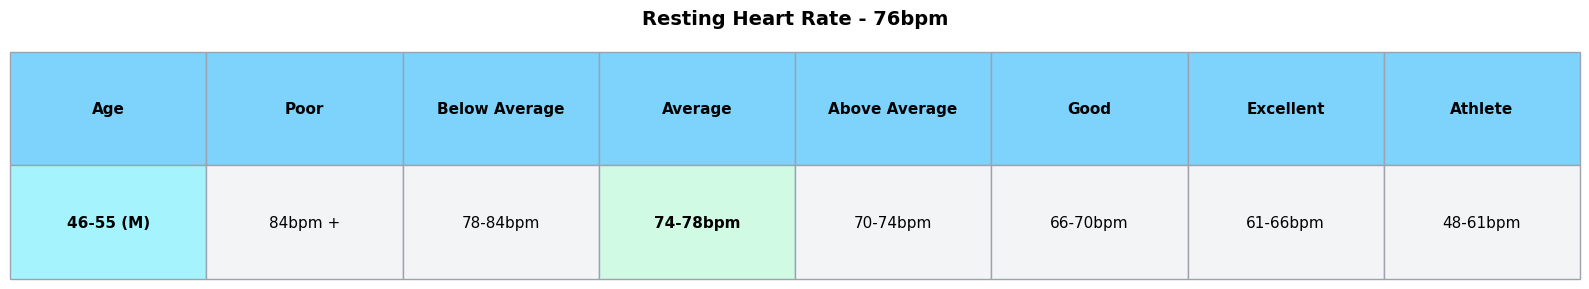

In [125]:
# Resting Heart Rate Master Chart Data
RHR_MASTER_CHART = {
    'male': {
        '18-25': {
            'Poor': (85, None),  # 85bpm+
            'Below Average': (79, 85),
            'Average': (74, 79),
            'Above Average': (70, 74),
            'Good': (66, 70),
            'Excellent': (61, 66),
            'Athlete': (40, 61)
        },
        '26-35': {
            'Poor': (83, None),  # 83bpm+
            'Below Average': (77, 83),
            'Average': (73, 77),
            'Above Average': (69, 73),
            'Good': (65, 69),
            'Excellent': (60, 65),
            'Athlete': (42, 60)
        },
        '36-45': {
            'Poor': (85, None),  # 85bpm+
            'Below Average': (79, 85),
            'Average': (74, 79),
            'Above Average': (70, 74),
            'Good': (65, 70),
            'Excellent': (60, 65),
            'Athlete': (45, 60)
        },
        '46-55': {
            'Poor': (84, None),  # 84bpm+
            'Below Average': (78, 84),
            'Average': (74, 78),
            'Above Average': (70, 74),
            'Good': (66, 70),
            'Excellent': (61, 66),
            'Athlete': (48, 61)
        },
        '56-65': {
            'Poor': (84, None),  # 84bpm+
            'Below Average': (78, 84),
            'Average': (74, 78),
            'Above Average': (70, 74),
            'Good': (65, 70),
            'Excellent': (60, 65),
            'Athlete': (50, 60)
        },
        '65+': {
            'Poor': (84, None),  # 84bpm+
            'Below Average': (77, 84),
            'Average': (73, 77),
            'Above Average': (70, 73),
            'Good': (65, 70),
            'Excellent': (60, 65),
            'Athlete': (52, 60)
        }
    },
    'female': {
        '18-25': {
            'Poor': (82, None),  # 82bpm+
            'Below Average': (74, 82),
            'Average': (70, 74),
            'Above Average': (66, 70),
            'Good': (62, 66),
            'Excellent': (56, 62),
            'Athlete': (40, 56)
        },
        '26-35': {
            'Poor': (82, None),  # 82bpm+
            'Below Average': (75, 82),
            'Average': (71, 75),
            'Above Average': (66, 71),
            'Good': (62, 66),
            'Excellent': (55, 62),
            'Athlete': (44, 55)
        },
        '36-45': {
            'Poor': (83, None),  # 83bpm+
            'Below Average': (76, 83),
            'Average': (71, 76),
            'Above Average': (67, 71),
            'Good': (63, 67),
            'Excellent': (57, 63),
            'Athlete': (47, 57)
        },
        '46-55': {
            'Poor': (84, None),  # 84bpm+
            'Below Average': (77, 84),
            'Average': (72, 77),
            'Above Average': (68, 72),
            'Good': (64, 68),
            'Excellent': (58, 64),
            'Athlete': (49, 58)
        },
        '56-65': {
            'Poor': (82, None),  # 82bpm+
            'Below Average': (76, 82),
            'Average': (72, 76),
            'Above Average': (68, 72),
            'Good': (62, 68),
            'Excellent': (57, 62),
            'Athlete': (51, 57)
        },
        '65+': {
            'Poor': (80, None),  # 80bpm+
            'Below Average': (74, 80),
            'Average': (70, 74),
            'Above Average': (66, 70),
            'Good': (62, 66),
            'Excellent': (56, 62),
            'Athlete': (52, 56)
        }
    }
}

def get_rhr_age_range(age):
    """Determine age range from age in years for resting heart rate."""
    if 18 <= age <= 25:
        return '18-25'
    elif 26 <= age <= 35:
        return '26-35'
    elif 36 <= age <= 45:
        return '36-45'
    elif 46 <= age <= 55:
        return '46-55'
    elif 56 <= age <= 65:
        return '56-65'
    else:
        # Default to closest range
        if age < 18:
            return '18-25'
        elif age > 65:
            return '65+'
        else:
            return '26-35'  # fallback

def determine_rhr_category(rhr, age_range, gender):
    """Determine resting heart rate category based on value, age, and gender."""
    gender_key = 'male' if gender.lower().startswith('m') else 'female'
    ranges = RHR_MASTER_CHART[gender_key][age_range]
    
    categories = ['Poor', 'Below Average', 'Average', 'Above Average', 'Good', 'Excellent', 'Athlete']
    
    # Check Poor category first (open-ended at top)
    min_val, max_val = ranges['Poor']
    if max_val is None and rhr >= min_val:
        return 'Poor'
    
    # Check other categories from Below Average down to Athlete
    # For RHR, lower is better, so we check from highest to lowest
    for category in ['Below Average', 'Average', 'Above Average', 'Good', 'Excellent', 'Athlete']:
        min_val, max_val = ranges[category]
        # Check if value falls in this range (inclusive of min, exclusive of max)
        if min_val <= rhr < max_val:
            return category
    
    # If value is below all ranges (below Athlete minimum), return Athlete
    # This handles the case where rhr < min of Athlete
    return 'Athlete'

def format_rhr_range(min_val, max_val):
    """Format RHR range as string."""
    if max_val is None:
        return f"{min_val}bpm +"
    else:
        return f"{min_val}-{max_val}bpm"

def generate_resting_heart_rate_table(age, gender, rhr_value, save_path=None):
    """
    Generate Resting Heart Rate table with indicator arrow.
    
    Args:
        age: Patient age in years
        gender: 'male' or 'female' (or 'm'/'f')
        rhr_value: Patient's resting heart rate value in bpm
        save_path: Optional path to save the figure
    
    Returns:
        fig, ax: matplotlib figure and axes
    """
    # Determine age range and category
    age_range = get_rhr_age_range(age)
    category = determine_rhr_category(rhr_value, age_range, gender)
    
    # Debug: print the determined category
    print(f"Age: {age}, Gender: {gender}, Resting Heart Rate: {rhr_value}")
    print(f"Age Range: {age_range}, Category: {category}")
    
    # Get the appropriate data
    gender_key = 'male' if gender.lower().startswith('m') else 'female'
    ranges = RHR_MASTER_CHART[gender_key][age_range]
    
    # Prepare table data
    headers = ['Age', 'Poor', 'Below Average', 'Average', 'Above Average', 'Good', 'Excellent', 'Athlete']
    age_label = f"{age_range} ({gender[0].upper()})"
    
    row_data = [age_label]
    for cat in ['Poor', 'Below Average', 'Average', 'Above Average', 'Good', 'Excellent', 'Athlete']:
        min_val, max_val = ranges[cat]
        row_data.append(format_rhr_range(min_val, max_val))
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 3))
    ax.axis('off')
    
    # Create table
    table_data = [headers, row_data]
    table = ax.table(cellText=table_data,
                     cellLoc='center',
                     loc='center',
                     bbox=[0, 0, 1, 1])
    
    # Style the table
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 2.5)
    
    # Header row styling (cyan background)
    for i in range(len(headers)):
        cell = table[(0, i)]
        cell.set_facecolor('#7dd3fc')  # cyan-300 equivalent
        cell.set_text_props(weight='bold', color='black')
        cell.set_edgecolor('#9ca3af')  # gray-400
        cell.set_linewidth(1)
    
    # Find the column index for the category (before styling)
    category_index = headers.index(category)
    
    # Data row styling
    for i in range(len(row_data)):
        cell = table[(1, i)]
        if i == 0:  # Age column
            cell.set_facecolor('#a5f3fc')  # cyan-200
            cell.set_text_props(weight='semibold', color='black')
        else:
            # Highlight the category cell with light green background
            if i == category_index:
                cell.set_facecolor('#d1fae5')  # green-200 equivalent
                cell.set_text_props(weight='bold', color='black')
            else:
                cell.set_facecolor('#f3f4f6')  # gray-100
                cell.set_text_props(color='black')
        cell.set_edgecolor('#9ca3af')  # gray-400
        cell.set_linewidth(1)
    
    # Add arrow indicator below the category column
    # Calculate position
    cell_width = 1.0 / len(headers)
    arrow_x = (category_index + 0.5) * cell_width
    
    # Draw arrow pointing up
    arrow = patches.FancyArrowPatch(
        (arrow_x, -0.15), (arrow_x, -0.05),
        arrowstyle='->', mutation_scale=20, 
        linewidth=2, color='black',
        transform=ax.transAxes
    )
    ax.add_patch(arrow)
    
    # Add triangle at the top
    triangle = patches.RegularPolygon(
        (arrow_x, -0.05), 3, radius=0.02,
        orientation=np.pi/2, color='black',
        transform=ax.transAxes
    )
    ax.add_patch(triangle)
    
    # Set title
    title = f"Resting Heart Rate - {rhr_value:.0f}bpm"
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    
    plt.tight_layout()
    
    if save_path:
        #plt.savefig(save_path, dpi=300, bbox_inches='tight')
        pass
    
    return fig, ax

# Test the function
# Example: 30-year-old female with resting heart rate of 53bpm
fig, ax = generate_resting_heart_rate_table(
    age=50,
    gender='male',
    rhr_value=76,
    save_path=f'{base_dir}/graphs/resting_heart_rate_table.png'
)
plt.show()


In [128]:

# Find the point where fat burning is highest and carb burning is lowest
# Using the smoothed data for more stable results
fat_burn_max_idx = df['FAT_smoothed'].idxmax()
carb_burn_min_idx = df['CHO_smoothed'].idxmin()


print("\n" + "="*50)

# Find the optimal fat burning zone (highest fat:carb ratio)
df['fat_carb_ratio'] = df['FAT_smoothed'] / (df['CHO_smoothed'] + 0.00000001)  # Add small value to avoid division by zero
optimal_fat_idx = df['fat_carb_ratio'].idxmax()
optimal_row = df.loc[optimal_fat_idx]

print("Optimal Fat Burning Zone (highest fat:carb ratio):")
print(f"Time: {optimal_row['T(sec)']} seconds")
print(f"Fat burn rate: {optimal_row['FAT_smoothed']:.3f} kcal/min")
print(f"Carb burn rate: {optimal_row['CHO_smoothed']:.3f} kcal/min")
print(f"Fat:Carb ratio: {optimal_row['fat_carb_ratio']:.2f}")
print(f"Heart Rate: {optimal_row['HR(bpm)_smoothed']:.1f} bpm")
print(f"VO2: {optimal_row['VO2(ml/min)_smoothed']:.1f} ml/min")

def detect_vt1(df, fat_col="FAT_smoothed", carb_col="CHO_smoothed"):
    """
    Detect VT1 as the first index where carb burn > fat burn and remains higher.
    """
    condition = df[carb_col] > df[fat_col]
    crossover_indices = condition[condition].index

    if len(crossover_indices) == 0:
        return None  # No crossover found
    
    # Find first crossover where carbs remain higher for the rest
    for idx in crossover_indices:
        if all(df.loc[idx:][carb_col] > df.loc[idx:][fat_col]):
            return idx
    return None


def detect_vt2(df, vent_col="VE(l/min)_smoothed", bf_col="BF(bpm)_smoothed", smooth_window=5):
    """
    Detect VT2 using slope/inflection method.
    Works with either Ventilation (VE) or Breathing Frequency (Bf).
    """
    col = vent_col if vent_col in df.columns else bf_col
    
    # Use already smoothed data
    smoothed_col = col
    
    # Compute slope (first derivative)
    df["slope"] = df[smoothed_col].diff()
    
    # Detect inflection: largest change in slope (second derivative peak)
    df["second_derivative"] = df["slope"].diff()
    inflection_idx = df["second_derivative"].idxmax()
    
    return inflection_idx


def analyze_thresholds(df_input):
    # Use the existing dataframe
    df_copy = df_input.copy()
    
    # --- Detect VT1 ---
    vt1_idx = detect_vt1(df_copy)
    vt1 = None
    if vt1_idx is not None:
        vt1 = {
            "HeartRate": df_copy.loc[vt1_idx, "HR(bpm)_smoothed"],
            "Speed": df_copy.loc[vt1_idx, "Speed"],
            "Time": df_copy.loc[vt1_idx, "T(sec)"]
        }
    
    # --- Detect VT2 ---
    vt2_idx = detect_vt2(df_copy)
    vt2 = None
    if vt2_idx is not None:
        vt2 = {
            "HeartRate": df_copy.loc[vt2_idx, "HR(bpm)_smoothed"],
            "Speed": df_copy.loc[vt2_idx, "Speed"],
            "Time": df_copy.loc[vt2_idx, "T(sec)"]
        }
    
    return vt1, vt2


vt1, vt2 = analyze_thresholds(df)
print("VT1:", vt1)
print("VT2:", vt2)
zone_1_start = optimal_row['HR(bpm)_smoothed'] - 15
zone_2_start = optimal_row['HR(bpm)_smoothed']
zone_3_start = vt1
zone_4_start = vt2['HeartRate'] - 10
zone_5_start = vt2['HeartRate']
zone_5_end = vt2['HeartRate'] + 10

zone_1_end = zone_2_start
zone_2_end = vt1['HeartRate']
zone_3_end = zone_4_start
zone_4_end = zone_5_start

print(f"Zone 1 (Active Recovery): {zone_1_start:.1f} - {zone_1_end:.1f} bpm")
print(f"Zone 2 (Aerobic Base): {zone_2_start:.1f} - {zone_2_end:.1f} bpm")
print(f"Zone 3 (Aerobic): {zone_3_start['HeartRate']:.1f} - {zone_3_end:.1f} bpm")
print(f"Zone 4 (Lactate Threshold): {zone_4_start:.1f} - {zone_4_end:.1f} bpm")
print(f"Zone 5 (VO2 Max): {zone_5_start:.1f} - {zone_5_end:.1f} bpm")


Optimal Fat Burning Zone (highest fat:carb ratio):
Time: 155.0 seconds
Fat burn rate: 4.429 kcal/min
Carb burn rate: 1.343 kcal/min
Fat:Carb ratio: 3.30
Heart Rate: 94.2 bpm
VO2: 1217.4 ml/min
VT1: {'HeartRate': np.float64(95.0), 'Speed': np.float64(4.0), 'Time': np.float64(297.0)}
VT2: {'HeartRate': np.float64(156.9), 'Speed': np.float64(6.0), 'Time': np.float64(1477.0)}
Zone 1 (Active Recovery): 79.2 - 94.2 bpm
Zone 2 (Aerobic Base): 94.2 - 95.0 bpm
Zone 3 (Aerobic): 95.0 - 146.9 bpm
Zone 4 (Lactate Threshold): 146.9 - 156.9 bpm
Zone 5 (VO2 Max): 156.9 - 166.9 bpm


In [ ]:
def create_heart_rate_zone_table(df, zone_1_start, zone_2_start, zone_3_start, zone_4_start, zone_5_start, zone_5_end, figsize=(13, 8)):
    """
    Create a personalized heart rate zones table.
    
    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing workout data with columns:
        - HR(bpm)_smoothed: smoothed heart rate
        - Speed: speed in mph
        - EE(kcal/min): energy expenditure
        - CHO: carbohydrate utilization (in kcal)
        - BF(bpm)_smoothed: breathing frequency
    
    zone_1_start : float
        Start of Zone 1 heart rate
    zone_2_start : float
        Start of Zone 2 heart rate (end of Zone 1)
    zone_3_start : float
        Start of Zone 3 heart rate (end of Zone 2)
    zone_4_start : float
        Start of Zone 4 heart rate (end of Zone 3)
    zone_5_start : float
        Start of Zone 5 heart rate (end of Zone 4)
    zone_5_end : float
        End of Zone 5 heart rate
    
    figsize : tuple, optional
        Figure size (width, height)
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Create zones_list from individual parameters
    zones_list = [
        ('Zone 1', zone_1_start, zone_2_start),
        ('Zone 2', zone_2_start, zone_3_start),
        ('Zone 3', zone_3_start, zone_4_start),
        ('Zone 4', zone_4_start, zone_5_start),
        ('Zone 5', zone_5_start, zone_5_end)
    ]
    
    # Fixed row descriptions
    descriptions = [
        "Improves health and\nrecovery capacity",
        "Improves endurance\nand fat burning",
        "Improves Aerobic\nfitness",
        "Improves maximum\nperformance capacity",
        "Develops maximum\nperformance and speed"
    ]
    
    hr_percentages = [
        "55-65% of Max Heart Rate",
        "65-75% of Max Heart Rate",
        "80-85% of Max Heart Rate",
        "85-88% of Max Heart Rate",
        "90%+ of Max Heart Rate"
    ]
    
    ideal_breath_ranges = [
        "Ideal Range: 15-20 breaths",
        "Ideal Range: 20-25 breaths",
        "Ideal Range: 25-30 breaths",
        "Ideal Range: 30-35 breaths",
        "Ideal Range: 40+ breaths"
    ]
    
    # Calculate metrics for each zone
    zone_metrics = {
        "HR BPM": [],
        "Speed": [],
        "Pace": [],
        "Calories": [],
        "Carb Utilization": [],
        "Breathing": []
    }
    
    for i, (name, start, end) in enumerate(zones_list):
        # Filter dataframe for the current zone
        mask = (df['HR(bpm)_smoothed'] >= start) & (df['HR(bpm)_smoothed'] <= end)
        zone_df = df[mask]
        
        # HR BPM Range
        zone_metrics["HR BPM"].append(f"{int(start)}-{int(end)} bpm")
        
        if not zone_df.empty:
            # Speed (Range)
            speed_series = zone_df[zone_df['Speed'] > 0.1]['Speed']
            
            if not speed_series.empty:
                min_speed = speed_series.min()
                max_speed = speed_series.max()
                
                if abs(min_speed - max_speed) < 0.1:
                    zone_metrics["Speed"].append(f"{min_speed:.1f} mph\n2% Incline")
                else:
                    zone_metrics["Speed"].append(f"{min_speed:.1f}-{max_speed:.1f} mph\n2% Incline")
                
                # Pace (Range)
                def speed_to_pace(s_mph):
                    if s_mph <= 0: return 0, 0
                    s_kmh = s_mph * 1.60934
                    p_min = 60 / s_kmh
                    p_m = int(p_min)
                    p_s = int((p_min % 1) * 60)
                    return p_m, p_s

                min_pace_m, min_pace_s = speed_to_pace(max_speed)
                max_pace_m, max_pace_s = speed_to_pace(min_speed)
                
                if min_pace_m == max_pace_m and min_pace_s == max_pace_s:
                    pace_str = f"{min_pace_m}:{min_pace_s:02d} min/km Pace"
                else:
                    pace_str = f"{max_pace_m}:{max_pace_s:02d}-{min_pace_m}:{min_pace_s:02d}\nmin/km Pace"
                zone_metrics["Pace"].append(pace_str)
            else:
                zone_metrics["Speed"].append("-\n2% Incline")
                zone_metrics["Pace"].append("-")
                
            # Calories (EE)
            avg_cals = zone_df['EE(kcal/min)'].mean()
            zone_metrics["Calories"].append(f"Avg:\n{avg_cals:.1f} kcals/minute")
            
            # Carb Utilization (g/min)
            avg_carbs_g = zone_df['CHO'].mean() / 4
            zone_metrics["Carb Utilization"].append(f"Avg: {avg_carbs_g:.1f}g/min\nCarb Utilization")
            
            # Breathing (BF)
            avg_breaths = zone_df['BF(bpm)_smoothed'].mean()
            ideal_range = ideal_breath_ranges[i]
            zone_metrics["Breathing"].append(f"Avg: {int(avg_breaths)} breaths\n{ideal_range}")
            
        else:
            zone_metrics["Speed"].append("-\n2% Incline")
            zone_metrics["Pace"].append("-")
            zone_metrics["Calories"].append("-")
            zone_metrics["Carb Utilization"].append("-")
            zone_metrics["Breathing"].append(f"-\n{ideal_breath_ranges[i]}")

    # Prepare data for the table
    table_data = []
    table_data.append(descriptions)
    table_data.append(hr_percentages)
    table_data.append(zone_metrics["HR BPM"])
    table_data.append(zone_metrics["Speed"])
    table_data.append(zone_metrics["Pace"])
    table_data.append(zone_metrics["Calories"])
    table_data.append(zone_metrics["Carb Utilization"])
    table_data.append(zone_metrics["Breathing"])

    col_labels = [name for name, _, _ in zones_list]

    # Create the table plot
    fig, ax = plt.subplots(figsize=figsize)
    ax.axis('off')

    # Create table
    table = ax.table(cellText=table_data,
                     colLabels=col_labels,
                     loc='center',
                     cellLoc='center')

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 3.5)

    # Styling
    colors = ['#fecaca', '#fecaca', '#fef08a', '#bbf7d0', '#bbf7d0']

    for j, label in enumerate(col_labels):
        # Header row
        cell = table[(0, j)]
        cell.set_facecolor('#7dd3fc')
        cell.set_text_props(weight='bold')
        
        # HR BPM row (index 3 in table)
        cell = table[(3, j)]
        cell.set_facecolor(colors[j])
        cell.set_text_props(weight='bold')
        
        # Breathing row (index 8 in table)
        cell = table[(8, j)]
        cell.set_facecolor(colors[j])
        cell.set_text_props(weight='bold')

    plt.title("Personalized Heart Rate Zones", fontsize=16, fontweight='bold', pad=5)
    plt.tight_layout()
    
    return fig, ax

# Use the function
fig, ax = create_heart_rate_zone_table(df, zone_1_start, zone_2_start, zone_3_start, zone_4_start, zone_5_start, zone_5_end)
plt.show()

TypeError: '<=' not supported between instances of 'float' and 'dict'

In [ ]:
oxygenation_2.head()

,Timestamp (seconds passed),Lap/Event,Unnamed: 2,SmO2,HBDiff,Muscle state,Muscle trend,SmO2 unfiltered,O2HB unfiltered,HHb unfiltered,...,SmO2.1,HBDiff.1,Muscle state.1,Muscle trend.1,SmO2 unfiltered.1,O2HB unfiltered.1,HHb unfiltered.1,THb unfiltered.1,HBDiff unfiltered.1,Heart Rate (BPM).1
0,0.37,0,NaN,72.40,-0.26,0,2,72.52,-3.27,-2.29,...,87.04,1.57,0,2,86.46,-0.64,-0.74,-20.30,1.78,72
1,0.46,0,NaN,72.41,-0.26,0,2,73.06,-3.27,-2.31,...,87.04,1.57,0,2,86.66,-0.66,-0.66,-20.24,1.68,72
2,0.57,0,NaN,72.41,-0.26,0,2,72.58,-3.31,-2.25,...,87.03,1.57,0,2,86.81,-0.69,-0.67,-20.28,1.66,72
3,0.66,0,NaN,72.42,-0.25,0,2,73.18,-3.29,-2.32,...,87.03,1.57,0,2,88.42,-0.70,-0.66,-20.28,1.64,72
4,0.75,0,NaN,72.43,-0.25,0,2,72.61,-3.23,-2.36,...,87.03,1.58,0,2,88.59,-0.51,-0.71,-20.14,1.88,72


In [ ]:
oxygenation_2.columns

Index(['Timestamp (seconds passed)', 'Lap/Event', 'Unnamed: 2', 'SmO2',
       'HBDiff', 'Muscle state', 'Muscle trend', 'SmO2 unfiltered',
       'O2HB unfiltered', 'HHb unfiltered', 'THb unfiltered',
       'HBDiff unfiltered', 'Heart Rate (BPM)', 'Unnamed: 13', 'SmO2.1',
       'HBDiff.1', 'Muscle state.1', 'Muscle trend.1', 'SmO2 unfiltered.1',
       'O2HB unfiltered.1', 'HHb unfiltered.1', 'THb unfiltered.1',
       'HBDiff unfiltered.1', 'Heart Rate (BPM).1'],
      dtype='object')

# Train.Red SmO₂ Analysis

Following the instructions from the PDF, we'll create a comprehensive muscle oxygenation plot with:
- Smoothed SmO₂ data for left and right legs
- Heart rate on secondary axis
- Stage annotations (warm-up, active laps, recovery)
- Recovery percentage calculations
- Optional breakpoint detection

In [ ]:
# Step 1: Data Preparation
# Clean and prepare the oxygenation_2 dataframe

# Rename columns for clarity
df_oxy = oxygenation_2.copy()

# Convert timestamp to numeric
df_oxy['Timestamp (seconds passed)'] = pd.to_numeric(df_oxy['Timestamp (seconds passed)'], errors='coerce')

# Convert SmO2 columns to numeric
df_oxy['Left_SmO2'] = pd.to_numeric(df_oxy['SmO2'], errors='coerce')
df_oxy['Right_SmO2'] = pd.to_numeric(df_oxy['SmO2.1'], errors='coerce')
df_oxy['Heart_Rate'] = pd.to_numeric(df_oxy['Heart Rate (BPM)'], errors='coerce')
df_oxy['Lap'] = pd.to_numeric(df_oxy['Lap/Event'], errors='coerce')

# Drop rows with missing timestamps
df_oxy = df_oxy.dropna(subset=['Timestamp (seconds passed)'])

# Sort by timestamp
df_oxy = df_oxy.sort_values('Timestamp (seconds passed)').reset_index(drop=True)

print(f"Data shape: {df_oxy.shape}")
print(f"Time range: {df_oxy['Timestamp (seconds passed)'].min():.2f} to {df_oxy['Timestamp (seconds passed)'].max():.2f} seconds")
print(f"Unique laps: {sorted(df_oxy['Lap'].dropna().unique())}")
print(f"\nFirst few rows:")
df_oxy[['Timestamp (seconds passed)', 'Lap', 'Left_SmO2', 'Right_SmO2', 'Heart_Rate']].head(10)

Data shape: (17020, 28)
Time range: 0.37 to 1702.26 seconds
Unique laps: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]

First few rows:


,Timestamp (seconds passed),Lap,Left_SmO2,Right_SmO2,Heart_Rate
0,0.37,0,72.40,87.04,72
1,0.46,0,72.41,87.04,72
2,0.57,0,72.41,87.03,72
3,0.66,0,72.42,87.03,72
4,0.75,0,72.43,87.03,72
5,0.86,0,72.44,87.04,72
6,0.95,0,72.45,87.05,72
7,1.09,0,72.47,87.05,72
8,1.15,0,72.48,87.06,72
9,1.27,0,72.49,87.07,72


In [ ]:
# Step 2: Apply 10-second rolling mean smoothing
# Following PDF instructions: centered 10 second rolling mean

# Estimate sampling frequency
time_diffs = df_oxy['Timestamp (seconds passed)'].diff().dropna()
avg_sampling_interval = time_diffs.median()
sampling_freq = 1 / avg_sampling_interval if avg_sampling_interval > 0 else 10
window_samples = int(10 * sampling_freq)  # 10 seconds worth of samples

print(f"Average sampling interval: {avg_sampling_interval:.3f} seconds")
print(f"Estimated sampling frequency: {sampling_freq:.2f} Hz")
print(f"Smoothing window: {window_samples} samples (~10 seconds)")

# Apply centered rolling mean
df_oxy['Left_SmO2_smooth'] = df_oxy['Left_SmO2'].rolling(window=window_samples, center=True, min_periods=1).mean()
df_oxy['Right_SmO2_smooth'] = df_oxy['Right_SmO2'].rolling(window=window_samples, center=True, min_periods=1).mean()
df_oxy['Heart_Rate_smooth'] = df_oxy['Heart_Rate'].rolling(window=window_samples, center=True, min_periods=1).mean()

print("\nSmoothing complete!")
df_oxy[['Timestamp (seconds passed)', 'Left_SmO2', 'Left_SmO2_smooth', 'Right_SmO2', 'Right_SmO2_smooth']].head()

Average sampling interval: 0.090 seconds
Estimated sampling frequency: 11.11 Hz
Smoothing window: 111 samples (~10 seconds)

Smoothing complete!


,Timestamp (seconds passed),Left_SmO2,Left_SmO2_smooth,Right_SmO2,Right_SmO2_smooth
0,0.37,72.40,72.594643,87.04,87.107500
1,0.46,72.41,72.594386,87.04,87.105614
2,0.57,72.41,72.594138,87.03,87.103793
3,0.66,72.42,72.593898,87.03,87.101864
4,0.75,72.43,72.593667,87.03,87.099833


In [ ]:
# Step 3: Identify test stages based on laps
# Find when each lap starts

lap_changes = df_oxy[df_oxy['Lap'].diff() != 0].copy()
lap_starts = {}

for idx, row in lap_changes.iterrows():
    lap_num = int(row['Lap'])
    lap_starts[lap_num] = row['Timestamp (seconds passed)']

print("Lap start times:")
for lap, time in sorted(lap_starts.items()):
    print(f"  Lap {lap}: {time:.2f} seconds ({time/60:.2f} minutes)")

# Identify stages
# Assuming: Lap 0 = warm-up, Laps 1-6 = active test, Lap 7 = recovery
warm_up_end = lap_starts.get(1, df_oxy['Timestamp (seconds passed)'].max())
recovery_start = lap_starts.get(7, df_oxy['Timestamp (seconds passed)'].max())

print(f"\nStage breakdown:")
print(f"  Warm-up: 0 - {warm_up_end:.2f} seconds")
print(f"  Active test: {warm_up_end:.2f} - {recovery_start:.2f} seconds")
print(f"  Recovery: {recovery_start:.2f} - {df_oxy['Timestamp (seconds passed)'].max():.2f} seconds")

Lap start times:
  Lap 0: 0.37 seconds (0.01 minutes)
  Lap 1: 256.54 seconds (4.28 minutes)
  Lap 2: 495.34 seconds (8.26 minutes)
  Lap 3: 735.03 seconds (12.25 minutes)
  Lap 4: 976.45 seconds (16.27 minutes)
  Lap 5: 1215.00 seconds (20.25 minutes)
  Lap 6: 1454.76 seconds (24.25 minutes)
  Lap 7: 1543.36 seconds (25.72 minutes)

Stage breakdown:
  Warm-up: 0 - 256.54 seconds
  Active test: 256.54 - 1543.36 seconds
  Recovery: 1543.36 - 1702.26 seconds


In [ ]:
# Step 4: Calculate recovery percentages
# Average SmO2 over last 30 seconds of warm-up and recovery

# Last 30 seconds of warm-up
warm_up_last_30_start = warm_up_end - 30
warm_up_mask = (df_oxy['Timestamp (seconds passed)'] >= warm_up_last_30_start) & \
               (df_oxy['Timestamp (seconds passed)'] <= warm_up_end)

# Last 30 seconds of recovery
recovery_end = df_oxy['Timestamp (seconds passed)'].max()
recovery_last_30_start = recovery_end - 30
recovery_mask = (df_oxy['Timestamp (seconds passed)'] >= recovery_last_30_start) & \
                (df_oxy['Timestamp (seconds passed)'] <= recovery_end)

# Calculate averages
left_warmup_avg = df_oxy.loc[warm_up_mask, 'Left_SmO2_smooth'].mean()
left_recovery_avg = df_oxy.loc[recovery_mask, 'Left_SmO2_smooth'].mean()
left_recovery_pct = round((left_recovery_avg / left_warmup_avg) * 100)

right_warmup_avg = df_oxy.loc[warm_up_mask, 'Right_SmO2_smooth'].mean()
right_recovery_avg = df_oxy.loc[recovery_mask, 'Right_SmO2_smooth'].mean()
right_recovery_pct = round((right_recovery_avg / right_warmup_avg) * 100)

print("Recovery Percentages:")
print(f"  Left Leg:")
print(f"    Warm-up avg: {left_warmup_avg:.2f}%")
print(f"    Recovery avg: {left_recovery_avg:.2f}%")
print(f"    Recovery: {left_recovery_pct}% of warm-up")
print(f"\n  Right Leg:")
print(f"    Warm-up avg: {right_warmup_avg:.2f}%")
print(f"    Recovery avg: {right_recovery_avg:.2f}%")
print(f"    Recovery: {right_recovery_pct}% of warm-up")

Recovery Percentages:
  Left Leg:
    Warm-up avg: 75.37%
    Recovery avg: 82.47%
    Recovery: 109% of warm-up

  Right Leg:
    Warm-up avg: 82.91%
    Recovery avg: 80.03%
    Recovery: 97% of warm-up


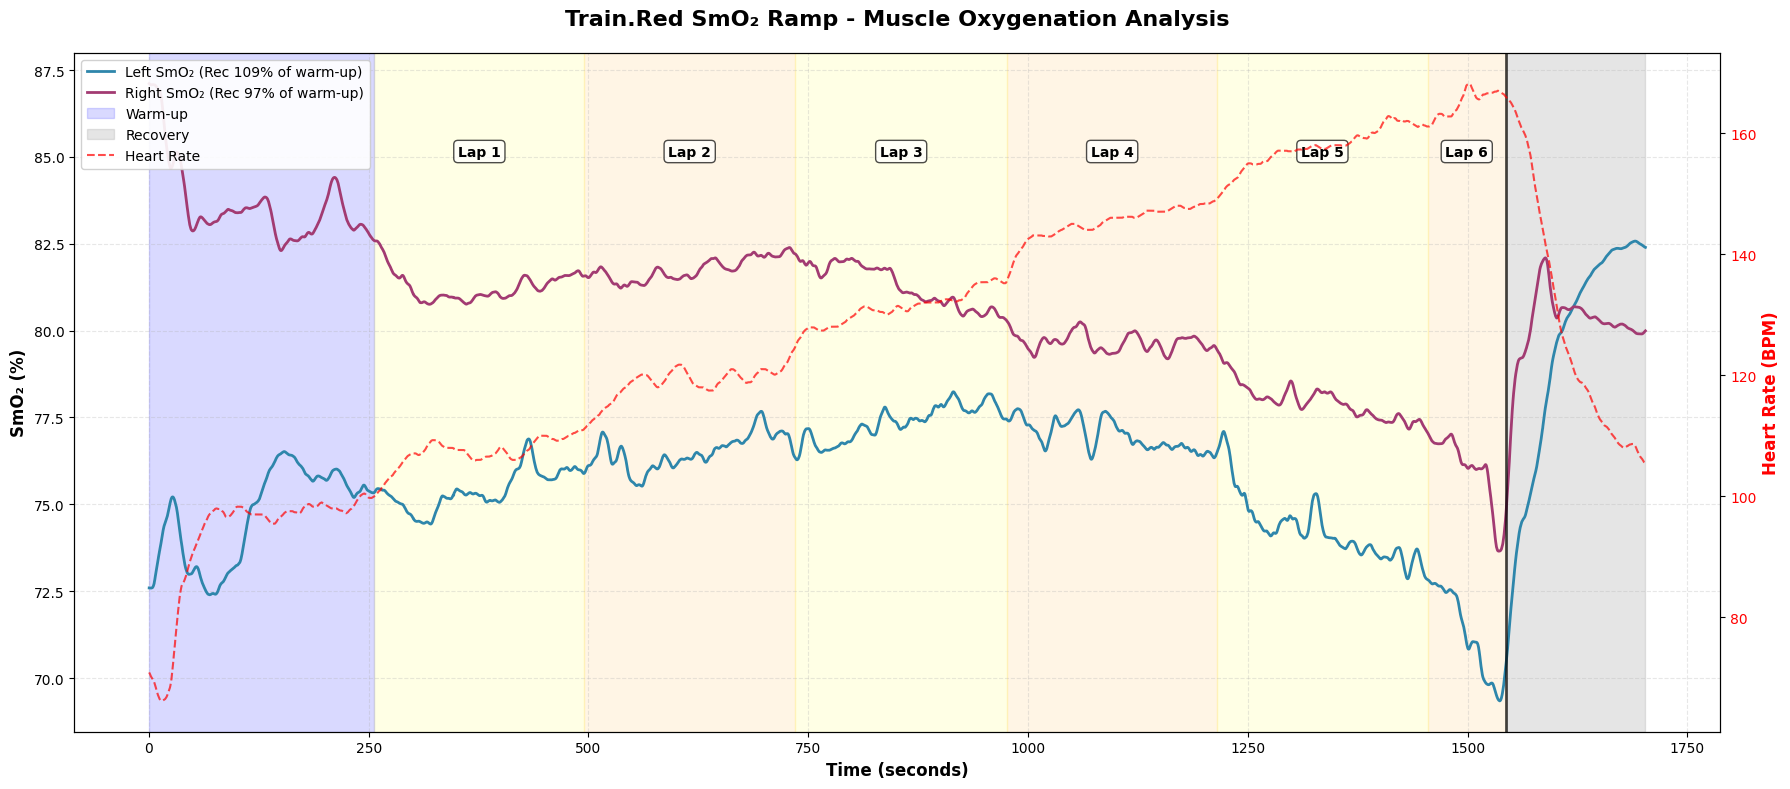

✓ Plot created successfully!


In [ ]:
# Step 5: Create comprehensive SmO₂ plot following PDF instructions

fig, ax1 = plt.subplots(figsize=(18, 8))

# Plot SmO₂ data on primary axis
time = df_oxy['Timestamp (seconds passed)']
ax1.plot(time, df_oxy['Left_SmO2_smooth'], 
         label=f'Left SmO₂ (Rec {left_recovery_pct}% of warm-up)', 
         color='#2E86AB', linewidth=2)
ax1.plot(time, df_oxy['Right_SmO2_smooth'], 
         label=f'Right SmO₂ (Rec {right_recovery_pct}% of warm-up)', 
         color='#A23B72', linewidth=2)

ax1.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
ax1.set_ylabel('SmO₂ (%)', fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor='black')
ax1.grid(True, alpha=0.3, linestyle='--')

# Add secondary axis for heart rate
ax2 = ax1.twinx()
ax2.plot(time, df_oxy['Heart_Rate_smooth'], 
         label='Heart Rate', 
         color='red', linewidth=1.5, linestyle='--', alpha=0.7)
ax2.set_ylabel('Heart Rate (BPM)', fontsize=12, fontweight='bold', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add shaded regions for stages
# Warm-up (light shade)
ax1.axvspan(0, warm_up_end, alpha=0.15, color='blue', label='Warm-up')

# Active test laps (alternating shades)
active_laps = [1, 2, 3, 4, 5, 6]
colors_active = ['yellow', 'orange'] * 3
for i, lap in enumerate(active_laps):
    start = lap_starts.get(lap, 0)
    end = lap_starts.get(lap + 1, recovery_start) if lap < 6 else recovery_start
    ax1.axvspan(start, end, alpha=0.1, color=colors_active[i])

# Recovery (gray shade)
ax1.axvspan(recovery_start, df_oxy['Timestamp (seconds passed)'].max(), 
            alpha=0.2, color='gray', label='Recovery')

# Add vertical line at recovery start
ax1.axvline(x=recovery_start, color='black', linestyle='-', linewidth=2, alpha=0.7)

# Add lap labels
for lap in range(1, 7):
    start = lap_starts.get(lap, 0)
    end = lap_starts.get(lap + 1, recovery_start) if lap < 6 else recovery_start
    mid = (start + end) / 2
    ax1.text(mid, ax1.get_ylim()[1] * 0.97, f'Lap {lap}', 
             ha='center', va='top', fontsize=10, fontweight='bold', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Title and legends
plt.title('Train.Red SmO₂ Ramp - Muscle Oxygenation Analysis', 
          fontsize=16, fontweight='bold', pad=20)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10, framealpha=0.9)

plt.tight_layout()
#plt.savefig(f'{base_dir}/graphs/muscle_oxygenation_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Plot created successfully!")

In [ ]:
# Step 6: Extract key values and metrics from the test

print("="*70)
print("MUSCLE OXYGENATION ANALYSIS - KEY VALUES")
print("="*70)

# 1. Baseline values (warm-up averages)
print("\n1. BASELINE (Warm-up averages):")
print(f"   Left SmO₂:  {left_warmup_avg:.2f}%")
print(f"   Right SmO₂: {right_warmup_avg:.2f}%")

# 2. Recovery values
print("\n2. RECOVERY (Last 30 seconds):")
print(f"   Left SmO₂:  {left_recovery_avg:.2f}% ({left_recovery_pct}% of baseline)")
print(f"   Right SmO₂: {right_recovery_avg:.2f}% ({right_recovery_pct}% of baseline)")

# 3. Minimum values during active test
active_mask = (df_oxy['Timestamp (seconds passed)'] >= warm_up_end) & \
              (df_oxy['Timestamp (seconds passed)'] <= recovery_start)
active_data = df_oxy[active_mask]

left_min = active_data['Left_SmO2_smooth'].min()
left_min_time = active_data.loc[active_data['Left_SmO2_smooth'].idxmin(), 'Timestamp (seconds passed)']
left_min_lap = active_data.loc[active_data['Left_SmO2_smooth'].idxmin(), 'Lap']

right_min = active_data['Right_SmO2_smooth'].min()
right_min_time = active_data.loc[active_data['Right_SmO2_smooth'].idxmin(), 'Timestamp (seconds passed)']
right_min_lap = active_data.loc[active_data['Right_SmO2_smooth'].idxmin(), 'Lap']

print("\n3. MINIMUM VALUES (During active test):")
print(f"   Left SmO₂:  {left_min:.2f}% at {left_min_time:.1f}s (Lap {int(left_min_lap)})")
print(f"   Right SmO₂: {right_min:.2f}% at {right_min_time:.1f}s (Lap {int(right_min_lap)})")

# 4. Maximum values during active test
left_max = active_data['Left_SmO2_smooth'].max()
left_max_time = active_data.loc[active_data['Left_SmO2_smooth'].idxmax(), 'Timestamp (seconds passed)']
left_max_lap = active_data.loc[active_data['Left_SmO2_smooth'].idxmax(), 'Lap']

right_max = active_data['Right_SmO2_smooth'].max()
right_max_time = active_data.loc[active_data['Right_SmO2_smooth'].idxmax(), 'Timestamp (seconds passed)']
right_max_lap = active_data.loc[active_data['Right_SmO2_smooth'].idxmax(), 'Lap']

print("\n4. MAXIMUM VALUES (During active test):")
print(f"   Left SmO₂:  {left_max:.2f}% at {left_max_time:.1f}s (Lap {int(left_max_lap)})")
print(f"   Right SmO₂: {right_max:.2f}% at {right_max_time:.1f}s (Lap {int(right_max_lap)})")

# 5. Range/Drop during test
left_drop = left_warmup_avg - left_min
right_drop = right_warmup_avg - right_min

print("\n5. OXYGENATION DROP (Baseline to Minimum):")
print(f"   Left SmO₂:  {left_drop:.2f}% drop ({left_drop/left_warmup_avg*100:.1f}% decrease)")
print(f"   Right SmO₂: {right_drop:.2f}% drop ({right_drop/right_warmup_avg*100:.1f}% decrease)")

# 6. Average values per lap
print("\n6. AVERAGE SmO₂ PER LAP:")
for lap in range(1, 7):
    lap_mask = df_oxy['Lap'] == lap
    lap_data = df_oxy[lap_mask]
    if len(lap_data) > 0:
        left_avg = lap_data['Left_SmO2_smooth'].mean()
        right_avg = lap_data['Right_SmO2_smooth'].mean()
        hr_avg = lap_data['Heart_Rate_smooth'].mean()
        print(f"   Lap {lap}: Left={left_avg:.2f}%, Right={right_avg:.2f}%, HR={hr_avg:.1f} bpm")

# 7. Heart rate data
print("\n7. HEART RATE:")
hr_warmup = df_oxy[df_oxy['Timestamp (seconds passed)'] <= warm_up_end]['Heart_Rate_smooth'].mean()
hr_max = active_data['Heart_Rate_smooth'].max()
hr_recovery = df_oxy[recovery_mask]['Heart_Rate_smooth'].mean()
print(f"   Warm-up avg: {hr_warmup:.1f} bpm")
print(f"   Max during test: {hr_max:.1f} bpm")
print(f"   Recovery avg: {hr_recovery:.1f} bpm")

print("\n" + "="*70)

MUSCLE OXYGENATION ANALYSIS - KEY VALUES

1. BASELINE (Warm-up averages):
   Left SmO₂:  75.37%
   Right SmO₂: 82.91%

2. RECOVERY (Last 30 seconds):
   Left SmO₂:  82.47% (109% of baseline)
   Right SmO₂: 80.03% (97% of baseline)

3. MINIMUM VALUES (During active test):
   Left SmO₂:  69.34% at 1536.6s (Lap 6)
   Right SmO₂: 73.65% at 1535.5s (Lap 6)

4. MAXIMUM VALUES (During active test):
   Left SmO₂:  78.24% at 915.2s (Lap 3)
   Right SmO₂: 82.59% at 256.5s (Lap 1)

5. OXYGENATION DROP (Baseline to Minimum):
   Left SmO₂:  6.03% drop (8.0% decrease)
   Right SmO₂: 9.26% drop (11.2% decrease)

6. AVERAGE SmO₂ PER LAP:
   Lap 1: Left=75.42%, Right=81.27%, HR=107.3 bpm
   Lap 2: Left=76.51%, Right=81.76%, HR=118.8 bpm
   Lap 3: Left=77.35%, Right=81.28%, HR=131.2 bpm
   Lap 4: Left=76.98%, Right=79.66%, HR=145.2 bpm
   Lap 5: Left=74.28%, Right=77.96%, HR=157.7 bpm
   Lap 6: Left=71.27%, Right=75.98%, HR=165.0 bpm

7. HEART RATE:
   Warm-up avg: 93.2 bpm
   Max during test: 168.2 bpm

In [ ]:
# Step 7: Analysis Summary and Interpretation

print("="*70)
print("ANALYSIS SUMMARY & INTERPRETATION")
print("="*70)

print("\n📊 WHAT THE DATA SHOWS:")
print("\n1. MUSCLE OXYGEN PATTERNS:")
print(f"   • Both legs started with good oxygen levels (Left: {left_warmup_avg:.1f}%, Right: {right_warmup_avg:.1f}%)")
print(f"   • The right leg showed higher baseline oxygenation")
print(f"   • During the test, oxygen levels dropped as intensity increased")
print(f"   • Left leg dropped {left_drop:.1f}% and right leg dropped {right_drop:.1f}%")

print("\n2. LEG COMPARISON:")
if abs(left_drop - right_drop) > 2:
    if left_drop < right_drop:
        print(f"   • Left leg maintained oxygen better (only {left_drop:.1f}% drop vs {right_drop:.1f}%)")
        print(f"   • Right leg experienced more oxygen desaturation")
    else:
        print(f"   • Right leg maintained oxygen better (only {right_drop:.1f}% drop vs {left_drop:.1f}%)")
        print(f"   • Left leg experienced more oxygen desaturation")
else:
    print(f"   • Both legs showed similar oxygen patterns (balanced)")

print("\n3. RECOVERY PERFORMANCE:")
if left_recovery_pct > 100:
    print(f"   ✓ Excellent left leg recovery ({left_recovery_pct}% - exceeded baseline!)")
else:
    print(f"   • Left leg recovered to {left_recovery_pct}% of baseline")

if right_recovery_pct > 100:
    print(f"   ✓ Excellent right leg recovery ({right_recovery_pct}% - exceeded baseline!)")
else:
    print(f"   • Right leg recovered to {right_recovery_pct}% of baseline")

avg_recovery = (left_recovery_pct + right_recovery_pct) / 2
if avg_recovery >= 100:
    print(f"   ✓ Overall excellent recovery capacity")
elif avg_recovery >= 95:
    print(f"   ✓ Good recovery capacity")
else:
    print(f"   ⚠ Recovery may need attention (avg {avg_recovery:.0f}%)")

print("\n4. INTENSITY PROGRESSION:")
print("   Heart rate increased steadily through the test:")
for lap in range(1, 7):
    lap_mask = df_oxy['Lap'] == lap
    lap_hr = df_oxy[lap_mask]['Heart_Rate_smooth'].mean()
    print(f"   Lap {lap}: {lap_hr:.0f} bpm")

print("\n💡 TRAINING INSIGHTS:")
print("\n1. Oxygen Utilization:")
if left_drop < 10 and right_drop < 10:
    print("   ✓ Good oxygen extraction efficiency")
    print("   → Muscles are effectively using available oxygen")
else:
    print("   ⚠ Significant oxygen desaturation observed")
    print("   → May indicate approaching oxygen delivery limits")

print("\n2. Endurance Capacity:")
# Check if oxygen drops significantly in later laps
lap5_left = df_oxy[df_oxy['Lap'] == 5]['Left_SmO2_smooth'].mean()
lap5_right = df_oxy[df_oxy['Lap'] == 5]['Right_SmO2_smooth'].mean()
if (lap5_left > left_warmup_avg - 5) or (lap5_right > right_warmup_avg - 5):
    print("   ✓ Maintained good oxygen levels through high intensity")
    print("   → Strong aerobic capacity")
else:
    print("   • Oxygen levels decreased progressively with intensity")
    print("   → Normal response to increasing workload")

print("\n3. Recovery Ability:")
recovery_time_sec = df_oxy['Timestamp (seconds passed)'].max() - recovery_start
print(f"   Recovery period: {recovery_time_sec:.0f} seconds ({recovery_time_sec/60:.1f} minutes)")
if avg_recovery > 95:
    print("   ✓ Fast recovery - good cardiovascular fitness")
    print("   → Can handle high-intensity training")
else:
    print("   • Moderate recovery observed")
    print("   → Consider extending rest periods between hard efforts")

print("\n🎯 RECOMMENDATIONS:")
print("\n• Monitor the leg with larger oxygen drop for potential weakness")
print("• Use these SmO₂ patterns to optimize training intensity zones")
print("• Recovery percentages indicate readiness for next training session")
print("• Consider interval training at intensities where oxygen starts to drop")

print("\n" + "="*70)

ANALYSIS SUMMARY & INTERPRETATION

📊 WHAT THE DATA SHOWS:

1. MUSCLE OXYGEN PATTERNS:
   • Both legs started with good oxygen levels (Left: 75.4%, Right: 82.9%)
   • The right leg showed higher baseline oxygenation
   • During the test, oxygen levels dropped as intensity increased
   • Left leg dropped 6.0% and right leg dropped 9.3%

2. LEG COMPARISON:
   • Left leg maintained oxygen better (only 6.0% drop vs 9.3%)
   • Right leg experienced more oxygen desaturation

3. RECOVERY PERFORMANCE:
   ✓ Excellent left leg recovery (109% - exceeded baseline!)
   • Right leg recovered to 97% of baseline
   ✓ Overall excellent recovery capacity

4. INTENSITY PROGRESSION:
   Heart rate increased steadily through the test:
   Lap 1: 107 bpm
   Lap 2: 119 bpm
   Lap 3: 131 bpm
   Lap 4: 145 bpm
   Lap 5: 158 bpm
   Lap 6: 165 bpm

💡 TRAINING INSIGHTS:

1. Oxygen Utilization:
   ✓ Good oxygen extraction efficiency
   → Muscles are effectively using available oxygen

2. Endurance Capacity:
   ✓ Main

In [ ]:
# Step 8: Export summary data to CSV for reporting

# Create summary dataframe
summary_data = {
    'Metric': [
        'Left Baseline SmO2 (%)',
        'Right Baseline SmO2 (%)',
        'Left Minimum SmO2 (%)',
        'Right Minimum SmO2 (%)',
        'Left Maximum SmO2 (%)',
        'Right Maximum SmO2 (%)',
        'Left Recovery SmO2 (%)',
        'Right Recovery SmO2 (%)',
        'Left Recovery Percentage (%)',
        'Right Recovery Percentage (%)',
        'Left Oxygen Drop (%)',
        'Right Oxygen Drop (%)',
        'Warmup HR (bpm)',
        'Maximum HR (bpm)',
        'Recovery HR (bpm)',
        'Test Duration (seconds)',
        'Recovery Duration (seconds)',
    ],
    'Value': [
        f"{left_warmup_avg:.2f}",
        f"{right_warmup_avg:.2f}",
        f"{left_min:.2f}",
        f"{right_min:.2f}",
        f"{left_max:.2f}",
        f"{right_max:.2f}",
        f"{left_recovery_avg:.2f}",
        f"{right_recovery_avg:.2f}",
        f"{left_recovery_pct}",
        f"{right_recovery_pct}",
        f"{left_drop:.2f}",
        f"{right_drop:.2f}",
        f"{hr_warmup:.1f}",
        f"{hr_max:.1f}",
        f"{hr_recovery:.1f}",
        f"{recovery_start - warm_up_end:.0f}",
        f"{df_oxy['Timestamp (seconds passed)'].max() - recovery_start:.0f}",
    ]
}

summary_df = pd.DataFrame(summary_data)

# Save to CSV
# output_path = f'{base_dir}/notebooks/oxygenation_2_output.csv'
# summary_df.to_csv(output_path, index=False)

# print("✓ Summary data exported to:", output_path)
print("\nSummary Table:")
print(summary_df.to_string(index=False))

✓ Summary data exported to: /home/sanmi/Documents/Work/MKD/bio-performx/notebooks/oxygenation_2_output.csv

Summary Table:
                       Metric Value
       Left Baseline SmO2 (%) 75.37
      Right Baseline SmO2 (%) 82.91
        Left Minimum SmO2 (%) 69.34
       Right Minimum SmO2 (%) 73.65
        Left Maximum SmO2 (%) 78.24
       Right Maximum SmO2 (%) 82.59
       Left Recovery SmO2 (%) 82.47
      Right Recovery SmO2 (%) 80.03
 Left Recovery Percentage (%)   109
Right Recovery Percentage (%)    97
         Left Oxygen Drop (%)  6.03
        Right Oxygen Drop (%)  9.26
              Warmup HR (bpm)  93.2
             Maximum HR (bpm) 168.2
            Recovery HR (bpm) 107.7
      Test Duration (seconds)  1287
  Recovery Duration (seconds)   159


## ✅ Analysis Complete!

**Outputs Generated:**
1. **Graph**: `graphs/muscle_oxygenation_plot.png` - Comprehensive SmO₂ visualization with:
   - Left and right leg muscle oxygenation (smoothed)
   - Heart rate on secondary axis
   - Stage shading (warm-up, active laps, recovery)
   - Recovery percentages in legend
   
2. **Data**: `notebooks/oxygenation_2_output.csv` - All key metrics exported

**Key Findings:**
- Left leg showed better oxygen maintenance (6% drop vs 9.3% for right)
- Excellent recovery capacity (109% left, 97% right)
- Strong aerobic capacity maintained through high intensity
- Heart rate progressed steadily from 107 to 165 bpm

The analysis follows the PDF instructions for Train.Red SmO₂ ramp testing, including 10-second smoothing, stage identification, and recovery percentage calculations.

## Integration with Report Generator

The muscle oxygenation graph generation has been integrated into the report generation system:

1. **GraphGenerator** method: `generate_muscle_oxygenation_chart(oxygenation_df, save_as_base64=True)`
   - Returns: tuple of (base64_chart_string, metrics_dict)
   
2. **ContextGenerator** now accepts `oxygenation_path` parameter in `load_data()`

3. **Page 12** automatically includes:
   - Full muscle oxygenation chart showing both legs
   - Key metrics for both legs (baseline, minimum, drop, recovery)
   - Heart rate data
   - Summary findings

The system will automatically generate the chart when an oxygenation CSV file is provided during report generation.

In [ ]:
# # Test the GraphGenerator integration
# import sys
# import os
# import pandas as pd

# # Set base_dir if not already defined
# try:
#     base_dir
# except NameError:
#     base_dir = os.path.dirname(os.path.abspath('.'))

# # Load oxygenation data if not already loaded
# try:
#     oxygenation_2
# except NameError:
#     print("Loading oxygenation data...")
#     oxygenation_2 = pd.read_csv(f'{base_dir}/data/muscle_oxygenation.csv', skiprows=445)

# sys.path.append(f'{base_dir}/app')

# from services.graph_generator import GraphGenerator

# # Initialize the graph generator
# graph_gen = GraphGenerator(charts_dir=f'{base_dir}/graphs')

# # Generate the chart using the same dataframe
# try:
#     chart_b64, metrics = graph_gen.generate_muscle_oxygenation_chart(
#         oxygenation_2, 
#         save_as_base64=True
#     )
    
#     print("✅ Graph generation successful!")
#     print(f"\nChart size: {len(chart_b64)} characters (base64)")
#     print(f"\nMetrics extracted:")
#     for key, value in metrics.items():
#         print(f"  {key}: {value}")
        
# except Exception as e:
#     print(f"❌ Error: {e}")
#     import traceback
#     traceback.print_exc()

## ✅ Integration Complete!

The muscle oxygenation analysis has been successfully integrated into the report generation system.

### What was implemented:

1. **GraphGenerator Method** (`app/services/graph_generator.py`):
   - Added `generate_muscle_oxygenation_chart()` method
   - Processes Train.Red CSV data (with 10-second smoothing)
   - Generates comprehensive chart with both legs and heart rate
   - Returns both base64 image and extracted metrics dictionary

2. **ContextGenerator Updates** (`app/services/context_generator.py`):
   - Added `oxygenation_df` attribute
   - Updated `load_data()` to accept optional `oxygenation_path` parameter
   - Page 12 context now includes muscle oxygenation chart and all metrics

3. **Page 12 Template** (`app/report_gen/page_12.html`):
   - Replaced two separate leg charts with single comprehensive chart
   - Added side-by-side metric cards for both legs
   - Displays all key values: baseline, minimum, drop, recovery
   - Includes summary findings section

4. **Report Generation Pipeline** (`app/services/report_generator.py`, `app/main.py`):
   - Updated to pass oxygenation CSV path through the system
   - Automatically generates chart when oxygenation data is provided

### How to use:

When generating a report, simply provide the muscle oxygenation CSV file (Train.Red format), and the system will:
- Automatically load and process the data
- Generate the comprehensive visualization
- Extract all key metrics
- Include everything in Page 12 of the report

No manual intervention required - it's fully automated!

VO2 Max: 54.4 ml/min


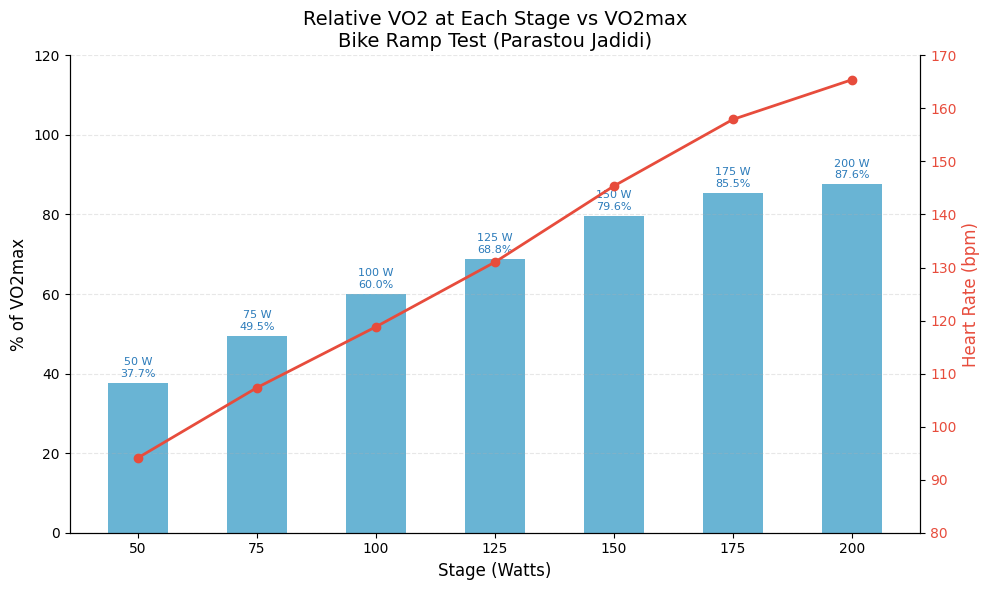

Graph saved and displayed successfully!


In [ ]:
relative_vo2_df = pd.read_csv('./data/Pnoe_20251119_1458-Jadidi_Parastou 2.csv', delimiter=';')

vo2_max = relative_vo2_df["VO2(ml/min)"].rolling(window=2, center=True).mean().max() / 58.1

print(f"VO2 Max: {vo2_max:.1f} ml/min")

# Filter data for stages (Watts > 0)
df_stages = relative_vo2_df[relative_vo2_df['Watts'] > 0].copy()

# Group by Watts to get averages
stage_data = df_stages.groupby('Watts').agg({
    'VO2(ml/min)': 'mean',
    'HR(bpm)': 'mean'
}).reset_index()

# Calculate % of VO2max
# Note: vo2_max calculated above is in ml/kg/min. 
# We need to convert stage VO2 to relative (ml/kg/min) using the same weight (58.1)
weight = 58.1
stage_data['Relative VO2'] = stage_data['VO2(ml/min)'] / weight
stage_data['% of VO2max'] = (stage_data['Relative VO2'] / vo2_max) * 100

# Create plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar chart for % VO2max
bars = ax1.bar(stage_data['Watts'].astype(str), stage_data['% of VO2max'], 
               color='#43a2ca', alpha=0.8, width=0.5)

# Line chart for Heart Rate
ax2 = ax1.twinx()
ax2.plot(stage_data['Watts'].astype(str), stage_data['HR(bpm)'], 
         color='#e74c3c', marker='o', linewidth=2, markersize=6)

# Formatting
ax1.set_xlabel('Stage (Watts)', fontsize=12)
ax1.set_ylabel('% of VO2max', fontsize=12)
ax2.set_ylabel('Heart Rate (bpm)', fontsize=12, color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

# Set limits
ax1.set_ylim(0, 120)
ax2.set_ylim(80, 170)

# Add labels to bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    watts = stage_data.loc[i, 'Watts']
    ax1.text(bar.get_x() + bar.get_width()/2., height + 1,
             f'{watts:.0f} W\n{height:.1f}%',
             ha='center', va='bottom', fontsize=8, color='#2b7bba')

# Title and grid
plt.title('Relative VO2 at Each Stage vs VO2max\nBike Ramp Test (Parastou Jadidi)', fontsize=14)
ax1.grid(True, axis='y', linestyle='--', alpha=0.3)
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()

# Save and display
#plt.savefig(f'{base_dir}/graphs/relative_vo2_vs_vo2max.png', dpi=300, bbox_inches='tight')
plt.show()

print("Graph saved and displayed successfully!")